In [81]:
# =============================================================================
# SECTION 1: DATA INFRASTRUCTURE AND METHODOLOGICAL SETUP
# =============================================================================

from __future__ import annotations
from pathlib import Path
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns
import yaml
import json
import random
import sys
import warnings
from datetime import datetime
from typing import Callable, Any
from scipy import stats
import scipy
from scipy.stats import skew, kurtosis, shapiro, jarque_bera, spearmanr, pearsonr, linregress
from IPython.display import display, Markdown, HTML

# Suppress specific warnings for cleaner output
warnings.filterwarnings('ignore', category=FutureWarning)
pd.options.mode.copy_on_write = True

%matplotlib inline

# -----------------------------------------------------------------------------
# Repository and Path Configuration
# -----------------------------------------------------------------------------

def find_repo_root(start: Path | None = None) -> Path:
    """Locate the repository root by searching for data/ and notebooks/ directories."""
    start = start or Path.cwd()
    for p in [start] + list(start.parents):
        if (p / 'data').exists() and (p / 'notebooks').exists():
            return p
    raise ValueError('Repo root not found; expected data/ and notebooks/ in a parent directory')

ROOT = find_repo_root()

PATHS = {
    'data_processed': ROOT / 'data' / 'processed',
    'data_raw': ROOT / 'data' / 'raw',
}

NOTEBOOK_NAME = '02_efw_quinquennial_macro_presentable_extended'
OUT_ROOT = ROOT / 'outputs'
OUT_FIG = OUT_ROOT / 'figures' / NOTEBOOK_NAME
OUT_TAB = OUT_ROOT / 'tables' / NOTEBOOK_NAME
OUT_LOG = OUT_ROOT / 'logs' / NOTEBOOK_NAME
for p in [OUT_FIG, OUT_TAB, OUT_LOG]:
    p.mkdir(parents=True, exist_ok=True)

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# -----------------------------------------------------------------------------
# Academic Publication-Quality Plot Configuration
# -----------------------------------------------------------------------------

# Define a sophisticated color palette
PALETTE = {
    'primary': '#2C3E50',      # Dark blue-gray
    'secondary': '#E74C3C',    # Muted red
    'tertiary': '#27AE60',     # Green
    'quaternary': '#F39C12',   # Orange
    'quinary': '#8E44AD',      # Purple
    'light_gray': '#BDC3C7',
    'dark_gray': '#7F8C8D',
    'positive': '#27AE60',
    'negative': '#E74C3C',
    'neutral': '#3498DB',
}

# Extended palette for multiple categories
CATEGORY_COLORS = [
    '#2C3E50', '#E74C3C', '#27AE60', '#F39C12', '#8E44AD',
    '#3498DB', '#1ABC9C', '#E67E22', '#9B59B6', '#34495E'
]

# Configure matplotlib for publication-quality figures
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    # Figure
    'figure.dpi': 150,
    'figure.figsize': (8, 5),
    'figure.facecolor': 'white',
    'savefig.dpi': 300,
    'savefig.facecolor': 'white',
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    
    # Font (use a serif font for academic style)
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'font.size': 10,
    
    # Axes
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.labelweight': 'normal',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#333333',
    'axes.prop_cycle': plt.cycler('color', CATEGORY_COLORS),
    
    # Ticks
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    
    # Grid
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linewidth': 0.5,
    'grid.color': '#CCCCCC',
    
    # Legend
    'legend.fontsize': 9,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.edgecolor': '#CCCCCC',
    'legend.fancybox': False,
    
    # Lines
    'lines.linewidth': 1.5,
    'lines.markersize': 6,
})

# -----------------------------------------------------------------------------
# I/O Utilities
# -----------------------------------------------------------------------------

def read_parquet_pyarrow(path: str | Path) -> pd.DataFrame:
    """Read a parquet file using PyArrow backend."""
    table = pq.read_table(str(path))
    return table.to_pandas()


def _coerce_for_parquet(df: pd.DataFrame) -> pd.DataFrame:
    """Convert non-serializable dtypes for parquet output."""
    out = df.copy()
    for col in out.columns:
        dtype = out[col].dtype
        if isinstance(dtype, pd.IntervalDtype):
            out[col] = out[col].astype(str)
        elif isinstance(dtype, pd.CategoricalDtype):
            try:
                if isinstance(out[col].cat.categories.dtype, pd.IntervalDtype):
                    out[col] = out[col].astype(str)
            except Exception:
                pass
    return out


def write_parquet_pyarrow(df: pd.DataFrame, path: str | Path) -> None:
    """Write a DataFrame to parquet using PyArrow."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    safe = _coerce_for_parquet(df)
    table = pa.Table.from_pandas(safe, preserve_index=False)
    pq.write_table(table, str(path))


def save_table(df: pd.DataFrame, name: str, *, index: bool = False, also_md: bool = True, also_latex: bool = True) -> None:
    """Save a table in multiple formats (parquet, csv, markdown, LaTeX)."""
    write_parquet_pyarrow(df, OUT_TAB / f"{name}.parquet")
    df.to_csv(OUT_TAB / f"{name}.csv", index=index)
    if also_md:
        df_md = df.astype(object).where(pd.notna(df), None)
        (OUT_TAB / f"{name}.md").write_text(df_md.to_markdown(index=index, missingval=""))
    if also_latex:
        try:
            latex_str = df.to_latex(index=index, float_format="%.3f", na_rep="—")
            (OUT_TAB / f"{name}.tex").write_text(latex_str)
        except Exception:
            pass


def save_log(df: pd.DataFrame, name: str, *, index: bool = False) -> None:
    """Save a log DataFrame."""
    write_parquet_pyarrow(df, OUT_LOG / f"{name}.parquet")
    df.to_csv(OUT_LOG / f"{name}.csv", index=index)


def save_fig(name: str, fig=None, formats: list[str] = ['png', 'pdf']) -> None:
    """Save a figure in multiple formats."""
    fig = fig or plt.gcf()
    for fmt in formats:
        fig.savefig(OUT_FIG / f"{name}.{fmt}", bbox_inches='tight', dpi=300 if fmt == 'png' else None)


# -----------------------------------------------------------------------------
# Audit and Validation Utilities
# -----------------------------------------------------------------------------

AUDIT_LOG = []


def log_df(df: pd.DataFrame, step: str, keys: list[str] | None = None, notes: str = "") -> None:
    """Log DataFrame characteristics for audit trail."""
    row = {
        'step': step,
        'n_rows': int(len(df)),
        'n_cols': int(df.shape[1]),
        'n_iso3': int(df['iso3'].nunique(dropna=True)) if 'iso3' in df.columns else None,
        'notes': notes,
        'timestamp': datetime.now().isoformat(timespec='seconds'),
    }
    if keys:
        row['n_dupe_rows_on_keys'] = int(df.duplicated(subset=keys).sum())
    AUDIT_LOG.append(row)


def assert_unique(df: pd.DataFrame, keys: list[str], allow_na: bool = False) -> None:
    """Assert that a DataFrame has unique rows on specified keys."""
    if not allow_na and df[keys].isna().any().any():
        raise AssertionError(f"Missing values in key columns {keys}")
    dupes = df.duplicated(subset=keys)
    if dupes.any():
        raise AssertionError(f"Duplicate rows found on keys {keys}: {int(dupes.sum())}")


def assert_in_set(df: pd.DataFrame, col: str, allowed: set) -> None:
    """Assert that a column only contains allowed values."""
    bad = set(df[col].dropna().unique()) - set(allowed)
    if bad:
        raise AssertionError(f"Column {col} has values outside allowed set: {bad}")


def assert_bounds(df: pd.DataFrame, col: str, lo: float, hi: float, tol: float = 1e-9, allow_na: bool = True) -> None:
    """Assert that a column is within specified bounds."""
    s = df[col]
    if not allow_na:
        s = s.dropna()
    bad = s[(s < lo - tol) | (s > hi + tol)]
    if not bad.empty:
        raise AssertionError(f"Column {col} has {len(bad)} values outside bounds [{lo},{hi}]")


# -----------------------------------------------------------------------------
# Display Utilities
# -----------------------------------------------------------------------------

def show_table(df: pd.DataFrame, title: str | None = None, n: int | None = None, 
               precision: int = 3, highlight_extremes: bool = False) -> None:
    """Display a DataFrame with optional formatting."""
    if title:
        display(Markdown(f"**{title}**"))
    
    styled = df.head(n) if n else df
    
    # Apply numeric formatting
    formatters = {}
    for col in styled.columns:
        if pd.api.types.is_float_dtype(styled[col]):
            formatters[col] = lambda x: f"{x:.{precision}f}" if pd.notna(x) else "—"
    
    display(styled.style.format(formatters, na_rep="—"))


def section_header(title: str, level: int = 2) -> None:
    """Display a section header."""
    prefix = "#" * level
    display(Markdown(f"\n{prefix} {title}\n"))


# -----------------------------------------------------------------------------
# Statistical Utilities
# -----------------------------------------------------------------------------

def compute_distribution_stats(s: pd.Series, name: str = "variable") -> pd.DataFrame:
    """Compute comprehensive distribution statistics for a series."""
    s_clean = s.dropna()
    n = len(s_clean)
    
    if n == 0:
        return pd.DataFrame()
    
    stats_dict = {
        'Variable': name,
        'N': n,
        'Mean': s_clean.mean(),
        'Std. Dev.': s_clean.std(),
        'Min': s_clean.min(),
        'P5': s_clean.quantile(0.05),
        'P10': s_clean.quantile(0.10),
        'P25': s_clean.quantile(0.25),
        'Median': s_clean.median(),
        'P75': s_clean.quantile(0.75),
        'P90': s_clean.quantile(0.90),
        'P95': s_clean.quantile(0.95),
        'Max': s_clean.max(),
        'IQR': s_clean.quantile(0.75) - s_clean.quantile(0.25),
        'Skewness': skew(s_clean),
        'Kurtosis': kurtosis(s_clean),
        'Share > 0': (s_clean > 0).mean() if (s_clean != 0).any() else np.nan,
        'Share < 0': (s_clean < 0).mean() if (s_clean != 0).any() else np.nan,
    }
    
    # Normality test (only for sufficient sample size)
    if 8 <= n <= 5000:
        try:
            _, p_shapiro = shapiro(s_clean.sample(min(n, 5000), random_state=SEED))
            stats_dict['Shapiro-Wilk p'] = p_shapiro
        except Exception:
            stats_dict['Shapiro-Wilk p'] = np.nan
    
    if n >= 8:
        try:
            _, p_jb = jarque_bera(s_clean)
            stats_dict['Jarque-Bera p'] = p_jb
        except Exception:
            stats_dict['Jarque-Bera p'] = np.nan
    
    return pd.DataFrame([stats_dict])


def safe_log(s: pd.Series) -> pd.Series:
    """Compute natural logarithm, returning NaN for non-positive values."""
    return np.log(s.where(s > 0))


def winsorize(s: pd.Series, lower: float = 0.01, upper: float = 0.99) -> pd.Series:
    """Winsorize a series at specified percentiles."""
    lo_val = s.quantile(lower)
    hi_val = s.quantile(upper)
    return s.clip(lo_val, hi_val)


def corr_ci(r: float, n: int, alpha: float = 0.05) -> tuple[float, float]:
    """Fisher-z confidence interval for a correlation coefficient."""
    if r is None or not np.isfinite(r) or n is None or n < 4:
        return (np.nan, np.nan)
    r_clipped = float(np.clip(r, -0.999999, 0.999999))
    z = np.arctanh(r_clipped)
    se = 1 / np.sqrt(n - 3)
    z_crit = stats.norm.ppf(1 - alpha / 2)
    lo, hi = z - z_crit * se, z + z_crit * se
    return (np.tanh(lo), np.tanh(hi))


def safe_pearsonr(x, y, min_n: int = 30):
    """Return (r, p, n) with minimum-n and variance checks."""
    sub = pd.DataFrame({'x': x, 'y': y}).dropna()
    n = len(sub)
    if n < min_n or sub['x'].nunique() < 2 or sub['y'].nunique() < 2:
        return (np.nan, np.nan, n)
    r, p = pearsonr(sub['x'], sub['y'])
    return (r, p, n)


def safe_spearmanr(x, y, min_n: int = 30):
    """Return (rho, p, n) with minimum-n and variance checks."""
    sub = pd.DataFrame({'x': x, 'y': y}).dropna()
    n = len(sub)
    if n < min_n or sub['x'].nunique() < 2 or sub['y'].nunique() < 2:
        return (np.nan, np.nan, n)
    r, p = spearmanr(sub['x'], sub['y'])
    return (r, p, n)


def safe_linregress(x, y, min_n: int = 30):
    """Return (slope, intercept, r, p, se, n) with checks."""
    sub = pd.DataFrame({'x': x, 'y': y}).dropna()
    n = len(sub)
    if n < min_n or sub['x'].nunique() < 2 or sub['y'].nunique() < 2:
        return (np.nan, np.nan, np.nan, np.nan, np.nan, n)
    slope, intercept, r, p, se = linregress(sub['x'], sub['y'])
    return (slope, intercept, r, p, se, n)


def qcut_ranked(s: pd.Series, q: int = 5, labels=None):
    """Robust qcut using ranks to avoid duplicate edge errors."""
    ranked = s.rank(method='first')
    return pd.qcut(ranked, q=q, labels=labels)


# -----------------------------------------------------------------------------
# Version Logging
# -----------------------------------------------------------------------------

VERSIONS = {
    'python': sys.version.split()[0],
    'pandas': pd.__version__,
    'numpy': np.__version__,
    'pyarrow': pa.__version__,
    'matplotlib': plt.matplotlib.__version__,
    'scipy': scipy.__version__,
    'seaborn': sns.__version__,
    'run_timestamp': datetime.now().isoformat(timespec='seconds'),
    'notebook': NOTEBOOK_NAME,
    'seed': SEED,
}

with open(OUT_LOG / 'versions.json', 'w') as f:
    json.dump(VERSIONS, f, indent=2)

print("✓ Infrastructure configured successfully")
print(f"  Output directories: {OUT_FIG.relative_to(ROOT)}, {OUT_TAB.relative_to(ROOT)}")
print(f"  Random seed: {SEED}")


✓ Infrastructure configured successfully
  Output directories: outputs/figures/02_efw_quinquennial_macro_presentable_extended, outputs/tables/02_efw_quinquennial_macro_presentable_extended
  Random seed: 42


In [82]:
# =============================================================================
# SECTION 2: DATA LOADING AND PANEL CONSTRUCTION
# =============================================================================

section_header("Data Loading and Panel Construction")

# Load macro panel (WB + PWT + EFW)
PATH_MACRO = PATHS['data_processed'] / 'macro_panel.parquet'
macro = read_parquet_pyarrow(PATH_MACRO)

# Basic normalization
macro['iso3'] = macro['iso3'].astype('string').str.upper().str.strip()
macro['year'] = pd.to_numeric(macro['year'], errors='coerce')
macro = macro[macro['iso3'].str.len() == 3]
macro = macro[macro['year'].notna()]
macro['year'] = macro['year'].astype(int)

assert_unique(macro, ['iso3','year'])
log_df(macro, 'loaded_macro_panel', keys=['iso3','year'])

# Rename EFW columns to readable names
rename_efw = {
    'efw_Summary': 'efw_total',
    'efw_Area 1': 'efw_area1',   # Size of Government
    'efw_Area 2': 'efw_area2',   # Legal System & Property Rights
    'efw_Area 3': 'efw_area3',   # Sound Money
    'efw_Area 4': 'efw_area4',   # Freedom to Trade Internationally
    'efw_Area 5': 'efw_area5',   # Regulation
    'efw_Standard Deviation of the 5 EFW Areas': 'efw_sd_areas',
}
macro = macro.rename(columns={k: v for k, v in rename_efw.items() if k in macro.columns})

if 'efw_total' not in macro.columns:
    raise ValueError('efw_total not found in macro_panel.parquet')

# Quinquennial years (1970–2020)
QUINQUENNIAL_YEARS = [1970, 1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020]
panel = macro[macro['year'].isin(QUINQUENNIAL_YEARS)].copy()
assert_in_set(panel, 'year', set(QUINQUENNIAL_YEARS))

log_df(panel, 'panel_quinquennial_base', keys=['iso3','year'])

# Summary
print(f"✓ Panel constructed: {len(panel):,} country-year observations")
print(f"  Countries: {panel['iso3'].nunique()}")
print(f"  Years: {sorted(panel['year'].unique())}")
print(f"  Columns: {panel.shape[1]}")


## Data Loading and Panel Construction


✓ Panel constructed: 2,387 country-year observations
  Countries: 217
  Years: [1970, 1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020]
  Columns: 74


In [83]:
# =============================================================================
# Add Metadata: Region, Income Classification, Epochs
# =============================================================================

# Load metadata from EFW Excel
PATH_EFW = ROOT / 'efw.xlsx'
EFW_SHEET = 'EFW Panel Dataset'

meta_cols = ['ISO_Code', 'World Bank Region', 'World Bank Current Income Classification, 1990-Present']
try:
    ef_meta = pd.read_excel(PATH_EFW, sheet_name=EFW_SHEET, usecols=meta_cols)
except ImportError as e:
    raise ImportError("Reading efw.xlsx requires openpyxl. Install via `pip install openpyxl`.") from e

ef_meta = ef_meta.rename(columns={
    'ISO_Code': 'iso3',
    'World Bank Region': 'wb_region',
    'World Bank Current Income Classification, 1990-Present': 'wb_income'
})
ef_meta['iso3'] = ef_meta['iso3'].astype(str).str.upper().str.strip()

# Aggregate metadata: most common non-null value per country
meta_agg = (ef_meta
    .dropna(subset=['iso3'])
    .groupby('iso3')
    .agg({
        'wb_region': lambda s: s.dropna().mode().iloc[0] if not s.dropna().empty else pd.NA,
        'wb_income': lambda s: s.dropna().mode().iloc[0] if not s.dropna().empty else pd.NA,
    })
    .reset_index()
)

panel = panel.merge(meta_agg, on='iso3', how='left')
# Clean income labels (harmonize variants)
panel['wb_income'] = panel['wb_income'].astype('string').str.strip()
panel.loc[panel['wb_income'].isin(['nan', 'None', '<NA>']), 'wb_income'] = pd.NA

# Map variants like "High income: OECD" to base groups
def _simplify_income(x):
    if pd.isna(x):
        return pd.NA
    x = str(x).strip()
    if 'High income' in x:
        return 'High income'
    if 'Upper middle income' in x:
        return 'Upper middle income'
    if 'Lower middle income' in x:
        return 'Lower middle income'
    if 'Low income' in x:
        return 'Low income'
    return x

panel['wb_income_clean'] = panel['wb_income'].map(_simplify_income)


# Map World Bank regions to broader continental groups
REGION_TO_CONTINENT = {
    'Sub-Saharan Africa': 'Sub-Saharan Africa',
    'Middle East & North Africa': 'MENA',
    'South Asia': 'South Asia',
    'East Asia & Pacific': 'East Asia & Pacific',
    'Europe & North America': 'Europe & N. America',
    'Latin America & the Caribbean': 'Latin America',
    'North America': 'Europe & N. America',
}
panel['continent'] = panel['wb_region'].map(REGION_TO_CONTINENT).fillna('Other')

# Simplify income groups for analysis
INCOME_ORDER = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']
panel['wb_income_simple'] = panel['wb_income_clean'].where(panel['wb_income_clean'].isin(INCOME_ORDER), 'Other')

# Define historical epochs
EPOCH_BINS = [1969, 1984, 1999, 2009, 2020]
EPOCH_LABELS = ['1970–1984', '1985–1999', '2000–2009', '2010–2020']
panel['epoch'] = pd.cut(panel['year'], bins=EPOCH_BINS, labels=EPOCH_LABELS)

# Also create a "Cold War" vs "Post-Cold War" classification
panel['era'] = np.where(panel['year'] <= 1990, 'Cold War (≤1990)', 'Post-Cold War (>1990)')

log_df(panel, 'panel_with_metadata', keys=['iso3','year'])

# Display metadata summary
print(f"\n✓ Metadata merged")
print(f"\nRegion distribution:")
print(panel['continent'].value_counts().to_string())
print(f"\nIncome group distribution:")
print(panel['wb_income_simple'].value_counts().to_string())



✓ Metadata merged

Region distribution:
continent
Other                  1089
Sub-Saharan Africa      484
Latin America           286
MENA                    231
East Asia & Pacific     220
South Asia               55
Europe & N. America      22

Income group distribution:
wb_income_simple
Other    2387


In [84]:
# =============================================================================
# Construct Derived Variables: Lags, Changes, Logs
# =============================================================================

panel = panel.sort_values(['iso3', 'year'])

# Gap diagnostics for strict quinquennial changes
panel['year_lag'] = panel.groupby('iso3')['year'].shift(1)
panel['gap_years'] = panel['year'] - panel['year_lag']
panel['is_5y_gap'] = panel['gap_years'] == 5

# EFW lagged values and changes (strict 5y)
panel['efw_total_lag5_raw'] = panel.groupby('iso3')['efw_total'].shift(1)
panel['efw_total_lag5'] = panel['efw_total_lag5_raw'].where(panel['is_5y_gap'])
panel['efw_delta_5y'] = panel['efw_total'] - panel['efw_total_lag5']

# Annualized equivalent (robustness)
panel['efw_delta_5y_equiv'] = (panel['efw_total'] - panel['efw_total_lag5_raw']) * (5 / panel['gap_years'])
panel.loc[panel['gap_years'] <= 0, 'efw_delta_5y_equiv'] = np.nan

# 10-year changes (optional, strict 10y)
panel['efw_total_lag10_raw'] = panel.groupby('iso3')['efw_total'].shift(2)
panel['gap_years_10'] = panel['year'] - panel.groupby('iso3')['year'].shift(2)
panel['efw_total_lag10'] = panel['efw_total_lag10_raw'].where(panel['gap_years_10'] == 10)
panel['efw_delta_10y'] = panel['efw_total'] - panel['efw_total_lag10']

# EFW area changes (strict 5y)
for area in range(1, 6):
    col = f'efw_area{area}'
    if col in panel.columns:
        lag_raw = panel.groupby('iso3')[col].shift(1)
        panel[f'{col}_lag5'] = lag_raw.where(panel['is_5y_gap'])
        panel[f'{col}_delta_5y'] = panel[col] - panel[f'{col}_lag5']
        panel[f'{col}_delta_5y_equiv'] = (panel[col] - lag_raw) * (5 / panel['gap_years'])
        panel.loc[panel['gap_years'] <= 0, f'{col}_delta_5y_equiv'] = np.nan

# Macro change variables (strict 5y)
MACRO_CHANGE_VARS = [
    'macro_gdp_pc_real_log',
    'macro_gov_cons_gdp',
    'macro_trade_gdp',
    'macro_inflation_cpi',
    'macro_credit_private_gdp',
    'macro_inv_gdp',
]
for v in MACRO_CHANGE_VARS:
    if v in panel.columns:
        lag_raw = panel.groupby('iso3')[v].shift(1)
        panel[f'{v}_lag5'] = lag_raw.where(panel['is_5y_gap'])
        panel[f'{v}_delta_5y'] = panel[v] - panel[f'{v}_lag5']
        panel[f'{v}_delta_5y_equiv'] = (panel[v] - lag_raw) * (5 / panel['gap_years'])
        panel.loc[panel['gap_years'] <= 0, f'{v}_delta_5y_equiv'] = np.nan

# Define variable groups for analysis
MACRO_VARS = [v for v in [
    'macro_gdp_pc_real_log',
    'macro_gdp_growth',
    'macro_inflation_cpi',
    'macro_trade_gdp',
    'macro_gov_cons_gdp',
    'macro_inv_gdp',
    'macro_credit_private_gdp',
    'macro_debt_gdp',
    'macro_money_broad_gdp',
    'macro_natres_rents_gdp',
] if v in panel.columns]

PWT_VARS = [v for v in [
    'pwt_cgdpo',
    'pwt_ctfp',
    'pwt_rtfpna',
    'pwt_ck',
    'pwt_csh_i',
    'pwt_avh',
] if v in panel.columns]

EFW_VARS = [c for c in panel.columns if c.startswith('efw_') and not c.endswith('_lag5') and not c.endswith('_delta_5y')]

# Variable labels for display
VAR_LABELS = {
    'efw_total': 'EFW Total Index',
    'efw_area1': 'EFW Area 1: Size of Government',
    'efw_area2': 'EFW Area 2: Legal System',
    'efw_area3': 'EFW Area 3: Sound Money',
    'efw_area4': 'EFW Area 4: Trade Freedom',
    'efw_area5': 'EFW Area 5: Regulation',
    'macro_gdp_pc_real_log': 'Log Real GDP per capita',
    'macro_gdp_growth': 'GDP Growth (%)',
    'macro_inflation_cpi': 'Inflation (CPI, %)',
    'macro_trade_gdp': 'Trade (% of GDP)',
    'macro_gov_cons_gdp': 'Government Consumption (% of GDP)',
    'macro_inv_gdp': 'Investment (% of GDP)',
    'macro_credit_private_gdp': 'Private Credit (% of GDP)',
    'pwt_cgdpo': 'PWT: Output-side GDP',
    'pwt_ctfp': 'PWT: TFP at current PPPs',
    'pwt_rtfpna': 'PWT: TFP at constant prices',
}

# -----------------------------------------------------------------------------
# Gap Diagnostics (Table 29)
# -----------------------------------------------------------------------------

gap_dist = (panel['gap_years']
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
    .reset_index())

gap_dist.columns = ['Gap (years)', 'Count']
gap_dist['Share'] = gap_dist['Count'] / gap_dist['Count'].sum()

show_table(gap_dist, title='Table 29: Gap Diagnostics for Quinquennial Differences')
save_table(gap_dist, 'table29_gap_diagnostics')

valid_gaps = panel['gap_years'].notna()
share_5y = (panel.loc[valid_gaps, 'gap_years'] == 5).mean()
share_non5y = (panel.loc[valid_gaps, 'gap_years'] != 5).mean()
print(f"✓ Gap diagnostics: share gap=5y = {share_5y:.1%}, share gap≠5y = {share_non5y:.1%}")

print(f"✓ Derived variables constructed")
print(f"  Macro variables available: {len(MACRO_VARS)}")
print(f"  PWT variables available: {len(PWT_VARS)}")
print(f"  EFW variables: {len(EFW_VARS)}")




**Table 29: Gap Diagnostics for Quinquennial Differences**

,Gap (years),Count,Share
0,5,2170,1.000


✓ Gap diagnostics: share gap=5y = 100.0%, share gap≠5y = 0.0%
✓ Derived variables constructed
  Macro variables available: 10
  PWT variables available: 6
  EFW variables: 17


In [85]:
# =============================================================================
# PWT-Priority Macro Series Registry and Transformations
# =============================================================================

# Helper: choose first available series from candidates

def pick_series(candidates: list[str]) -> str | None:
    for c in candidates:
        if c in panel.columns:
            return c
    return None

# Resolve macro series (PWT-first; WB fallback)
MACRO_SERIES = {
    'gdp_level': ['pwt_rgdpo', 'pwt_rgdpna', 'pwt_cgdpo'],
    'gdp_pc': ['pwt_rgdpo', 'pwt_pop'],  # construct if both exist
    'exports_share': ['pwt_csh_x', 'macro_exports_gdp'],
    'imports_share': ['pwt_csh_m', 'macro_imports_gdp'],
    'investment_share': ['pwt_csh_i', 'macro_inv_gdp'],
    'inflation': ['macro_inflation_cpi'],
    'growth': ['macro_gdp_growth'],
    'consumption': ['pwt_rconna', 'pwt_ccon'],
    'expenditure': ['pwt_cda'],
    'capital_stock': ['pwt_rkna', 'pwt_ck'],
    'tfp': ['pwt_rtfpna', 'pwt_ctfp'],
    'welfare': ['pwt_cwtfp'],
    'irr': ['pwt_irr'],
    'hc': ['pwt_hc'],
}

macro_series_resolved = []

# GDP per capita (constructed)
if 'pwt_rgdpo' in panel.columns and 'pwt_pop' in panel.columns:
    panel['pwt_rgdpo_pc'] = panel['pwt_rgdpo'] / panel['pwt_pop']
    gdp_pc_col = 'pwt_rgdpo_pc'
    gdp_pc_source = 'PWT'
else:
    gdp_pc_col = 'macro_gdp_pc_real_log' if 'macro_gdp_pc_real_log' in panel.columns else None
    gdp_pc_source = 'WB' if gdp_pc_col else None

# GDP level
_gdp_col = pick_series(MACRO_SERIES['gdp_level'])
_gdp_source = 'PWT' if _gdp_col and _gdp_col.startswith('pwt_') else ('WB' if _gdp_col else None)

# Growth fallback if missing
if MACRO_SERIES['growth'][0] not in panel.columns and _gdp_col is not None:
    # use log growth of real GDP (approx)
    panel['macro_gdp_growth_fallback'] = panel.groupby('iso3')[_gdp_col].apply(lambda s: np.log(s) - np.log(s.shift(1)))
    MACRO_SERIES['growth'] = ['macro_gdp_growth_fallback']

# Resolve each concept
for concept, candidates in MACRO_SERIES.items():
    if concept == 'gdp_pc':
        if gdp_pc_col is not None:
            macro_series_resolved.append({
                'concept': concept,
                'column': gdp_pc_col,
                'source': gdp_pc_source,
                'type': 'level',
            })
        continue
    col = pick_series(candidates)
    if col is None:
        continue
    source = 'PWT' if col.startswith('pwt_') else 'WB'
    # classify type
    if 'share' in concept or concept in ['inflation', 'growth']:
        vtype = 'rate'
    else:
        vtype = 'level'
    macro_series_resolved.append({
        'concept': concept,
        'column': col,
        'source': source,
        'type': vtype,
    })

# Add GDP level explicitly
if _gdp_col is not None:
    macro_series_resolved.append({
        'concept': 'gdp_level',
        'column': _gdp_col,
        'source': _gdp_source,
        'type': 'level',
    })

# Registry table
registry_df = pd.DataFrame(macro_series_resolved).drop_duplicates(subset=['concept'])
registry_df['n_obs'] = registry_df['column'].apply(lambda c: panel[c].notna().sum() if c in panel.columns else 0)
registry_df = registry_df[['concept', 'column', 'source', 'type', 'n_obs']]
show_table(registry_df, title='Table 35: Macro Series Registry (PWT-priority)')
save_table(registry_df, 'table35_macro_series_registry')

# Transformations: log and 5y differences (strict)
for _, row in registry_df.iterrows():
    col = row['column']
    if col not in panel.columns:
        continue
    if row['type'] == 'level':
        if (panel[col] > 0).mean() > 0.8:
            panel[f'log_{col}'] = safe_log(panel[col])
            lag_raw = panel.groupby('iso3')[f'log_{col}'].shift(1)
            panel[f'log_{col}_lag5'] = lag_raw.where(panel['is_5y_gap'])
            panel[f'log_{col}_delta_5y'] = panel[f'log_{col}'] - panel[f'log_{col}_lag5']
        # level changes
        lag_raw = panel.groupby('iso3')[col].shift(1)
        panel[f'{col}_lag5'] = lag_raw.where(panel['is_5y_gap'])
        panel[f'{col}_delta_5y'] = panel[col] - panel[f'{col}_lag5']
    else:
        # rate/share: use level and delta
        lag_raw = panel.groupby('iso3')[col].shift(1)
        panel[f'{col}_lag5'] = lag_raw.where(panel['is_5y_gap'])
        panel[f'{col}_delta_5y'] = panel[col] - panel[f'{col}_lag5']

print("✓ Macro series registry and transformations complete")



**Table 35: Macro Series Registry (PWT-priority)**

,concept,column,source,type,n_obs
0,gdp_level,pwt_rgdpo,PWT,level,1884
1,gdp_pc,pwt_rgdpo_pc,PWT,level,1884
2,exports_share,pwt_csh_x,PWT,rate,1884
3,imports_share,pwt_csh_m,PWT,rate,1884
4,investment_share,pwt_csh_i,PWT,rate,1884
5,inflation,macro_inflation_cpi,WB,rate,1600
6,growth,macro_gdp_growth,WB,rate,1988
7,consumption,pwt_rconna,PWT,level,1884
8,expenditure,pwt_cda,PWT,level,1884
9,capital_stock,pwt_rkna,PWT,level,1346


✓ Macro series registry and transformations complete


In [86]:
# =============================================================================
# SECTION 3: DESCRIPTIVE STATISTICS AND COVERAGE DIAGNOSTICS
# =============================================================================

section_header("Descriptive Statistics and Coverage Diagnostics")

# -----------------------------------------------------------------------------
# 3.1 EFW Summary Statistics
# -----------------------------------------------------------------------------

# Comprehensive distribution statistics for EFW total
efw_dist = compute_distribution_stats(panel['efw_total'], 'EFW Total')
show_table(efw_dist.T.reset_index().rename(columns={'index': 'Statistic', 0: 'Value'}), 
           title="Table 1: EFW Total Index — Distributional Statistics")
save_table(efw_dist, 'table1_efw_total_distribution')

# EFW by area
area_stats = []
for area in range(1, 6):
    col = f'efw_area{area}'
    if col in panel.columns:
        area_stat = compute_distribution_stats(panel[col], VAR_LABELS.get(col, col))
        area_stats.append(area_stat)

if area_stats:
    area_stats_df = pd.concat(area_stats, ignore_index=True)
    cols_display = ['Variable', 'N', 'Mean', 'Std. Dev.', 'Min', 'P25', 'Median', 'P75', 'Max', 'Skewness', 'Kurtosis']
    show_table(area_stats_df[[c for c in cols_display if c in area_stats_df.columns]], 
               title="Table 2: EFW by Area — Summary Statistics")
    save_table(area_stats_df, 'table2_efw_areas_distribution')

# -----------------------------------------------------------------------------
# 3.2 Coverage Analysis
# -----------------------------------------------------------------------------

# Missingness by variable
def compute_missingness(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """Compute missingness statistics for a list of columns."""
    results = []
    for col in cols:
        if col in df.columns:
            n_total = len(df)
            n_missing = df[col].isna().sum()
            results.append({
                'Variable': VAR_LABELS.get(col, col),
                'N Total': n_total,
                'N Missing': n_missing,
                'N Available': n_total - n_missing,
                'Missing %': 100 * n_missing / n_total,
            })
    return pd.DataFrame(results).sort_values('Missing %')

# EFW missingness
miss_efw = compute_missingness(panel, EFW_VARS)
save_table(miss_efw, 'table3_efw_missingness')

# Macro missingness
miss_macro = compute_missingness(panel, MACRO_VARS)
save_table(miss_macro, 'table4_macro_missingness')

# Combined display
print("EFW Coverage:")
display(miss_efw[['Variable', 'N Available', 'Missing %']].head(8))
print("\nMacro Coverage (best 8):")
display(miss_macro[['Variable', 'N Available', 'Missing %']].head(8))


## Descriptive Statistics and Coverage Diagnostics


**Table 1: EFW Total Index — Distributional Statistics**

,Statistic,Value
0,Variable,EFW Total
1,N,1465
2,Mean,6.123648
3,Std. Dev.,1.304140
4,Min,2.220675
5,P5,3.863027
6,P10,4.378711
7,P25,5.218062
8,Median,6.149967
9,P75,7.100766


**Table 2: EFW by Area — Summary Statistics**

,Variable,N,Mean,Std. Dev.,Min,P25,Median,P75,Max,Skewness,Kurtosis
0,EFW Area 1: Size of Government,1562,6.172,1.542,0.202,5.216,6.243,7.203,10.000,-0.381,0.533
1,EFW Area 2: Legal System,1705,5.074,1.834,0.556,3.695,4.913,6.196,9.243,0.382,-0.526
2,EFW Area 3: Sound Money,1496,7.015,2.113,0.010,5.977,7.043,8.829,10.000,-0.998,1.114
3,EFW Area 4: Trade Freedom,1293,6.419,2.071,0.008,5.464,6.641,7.998,10.000,-0.808,0.319
4,EFW Area 5: Regulation,1572,5.827,1.479,0.956,4.835,5.988,6.906,10.000,-0.295,-0.206


EFW Coverage:


,Variable,N Available,Missing %
2,EFW Area 2: Legal System,1705,28.571429
5,EFW Area 5: Regulation,1572,34.143276
1,EFW Area 1: Size of Government,1562,34.562212
13,efw_area2_delta_5y_equiv,1541,35.441977
3,EFW Area 3: Sound Money,1496,37.327189
0,EFW Total Index,1465,38.625890
6,efw_sd_areas,1465,38.625890
16,efw_area5_delta_5y_equiv,1408,41.013825



Macro Coverage (best 8):


,Variable,N Available,Missing %
0,Log Real GDP per capita,2028,15.039799
1,GDP Growth (%),1988,16.715543
9,macro_natres_rents_gdp,1950,18.307499
3,Trade (% of GDP),1615,32.341852
2,"Inflation (CPI, %)",1600,32.970256
4,Government Consumption (% of GDP),1554,34.897361
8,macro_money_broad_gdp,1490,37.578550
5,Investment (% of GDP),1485,37.788018


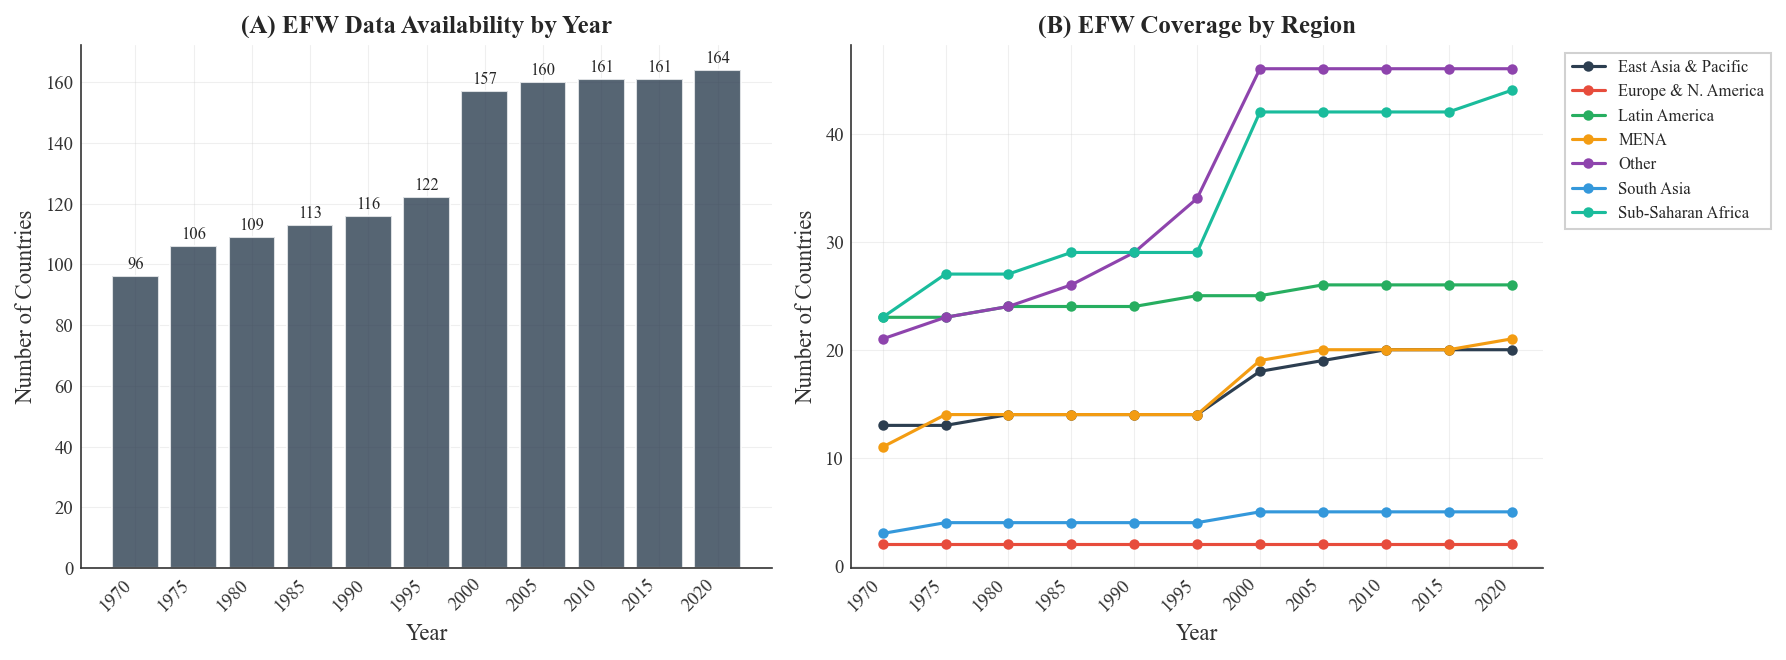


Figure 1: EFW quinquennial coverage (1970–2020)
Note: Coverage expands substantially after 1990, coinciding with post-Cold War data availability.


In [87]:
# -----------------------------------------------------------------------------
# 3.3 Coverage Visualization
# -----------------------------------------------------------------------------

# Figure 1: EFW Coverage Over Time
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel A: Number of countries with EFW data
cov_year = (panel.groupby('year')['efw_total']
    .apply(lambda s: s.notna().sum())
    .reset_index(name='n_countries')
)

ax1 = axes[0]
bars = ax1.bar(cov_year['year'], cov_year['n_countries'], 
               color=PALETTE['primary'], alpha=0.8, width=4, edgecolor='white')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Countries')
ax1.set_title('(A) EFW Data Availability by Year', fontweight='bold')
ax1.set_xticks(QUINQUENNIAL_YEARS)
ax1.set_xticklabels([str(y) for y in QUINQUENNIAL_YEARS], rotation=45, ha='right')

# Add value labels on bars
for bar, val in zip(bars, cov_year['n_countries']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             str(val), ha='center', va='bottom', fontsize=8)

# Panel B: Coverage by region over time
ax2 = axes[1]
cov_region = (panel.dropna(subset=['efw_total'])
    .groupby(['continent', 'year'])
    .size()
    .unstack(fill_value=0)
)

for i, cont in enumerate(cov_region.index):
    ax2.plot(cov_region.columns, cov_region.loc[cont], 
             marker='o', markersize=4, label=cont, color=CATEGORY_COLORS[i % len(CATEGORY_COLORS)])

ax2.set_xlabel('Year')
ax2.set_ylabel('Number of Countries')
ax2.set_title('(B) EFW Coverage by Region', fontweight='bold')
ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax2.set_xticks(QUINQUENNIAL_YEARS)
ax2.set_xticklabels([str(y) for y in QUINQUENNIAL_YEARS], rotation=45, ha='right')

plt.tight_layout()
save_fig('fig1_efw_coverage')
plt.show()

print("\nFigure 1: EFW quinquennial coverage (1970–2020)")
print("Note: Coverage expands substantially after 1990, coinciding with post-Cold War data availability.")

---

## Section I: EFW Levels — Cross-Sectional and Temporal Patterns

This section examines the distribution and evolution of EFW levels across time, regions, and income groups. We analyze both the overall trends and the heterogeneity across different country groupings.

**Table 5: EFW Total by Year — Summary Statistics**

,Year,N,Mean,Median,Std,CI_low,CI_high,P10,P90
0,1970,96,5.710,5.651,1.198,5.490,5.948,4.333,7.383
1,1975,106,5.322,5.168,1.297,5.085,5.576,3.654,7.112
2,1980,109,5.369,5.271,1.326,5.137,5.602,3.841,7.339
3,1985,113,5.432,5.402,1.429,5.181,5.697,3.758,7.454
4,1990,116,5.769,5.633,1.434,5.513,6.041,4.034,7.843
5,1995,122,6.167,6.198,1.321,5.922,6.415,4.339,7.809
6,2000,157,6.307,6.310,1.233,6.127,6.482,4.576,8.025
7,2005,160,6.521,6.542,1.121,6.360,6.705,5.075,7.925
8,2010,161,6.534,6.609,1.052,6.369,6.681,5.067,7.861
9,2015,161,6.672,6.750,1.072,6.501,6.825,5.139,7.980


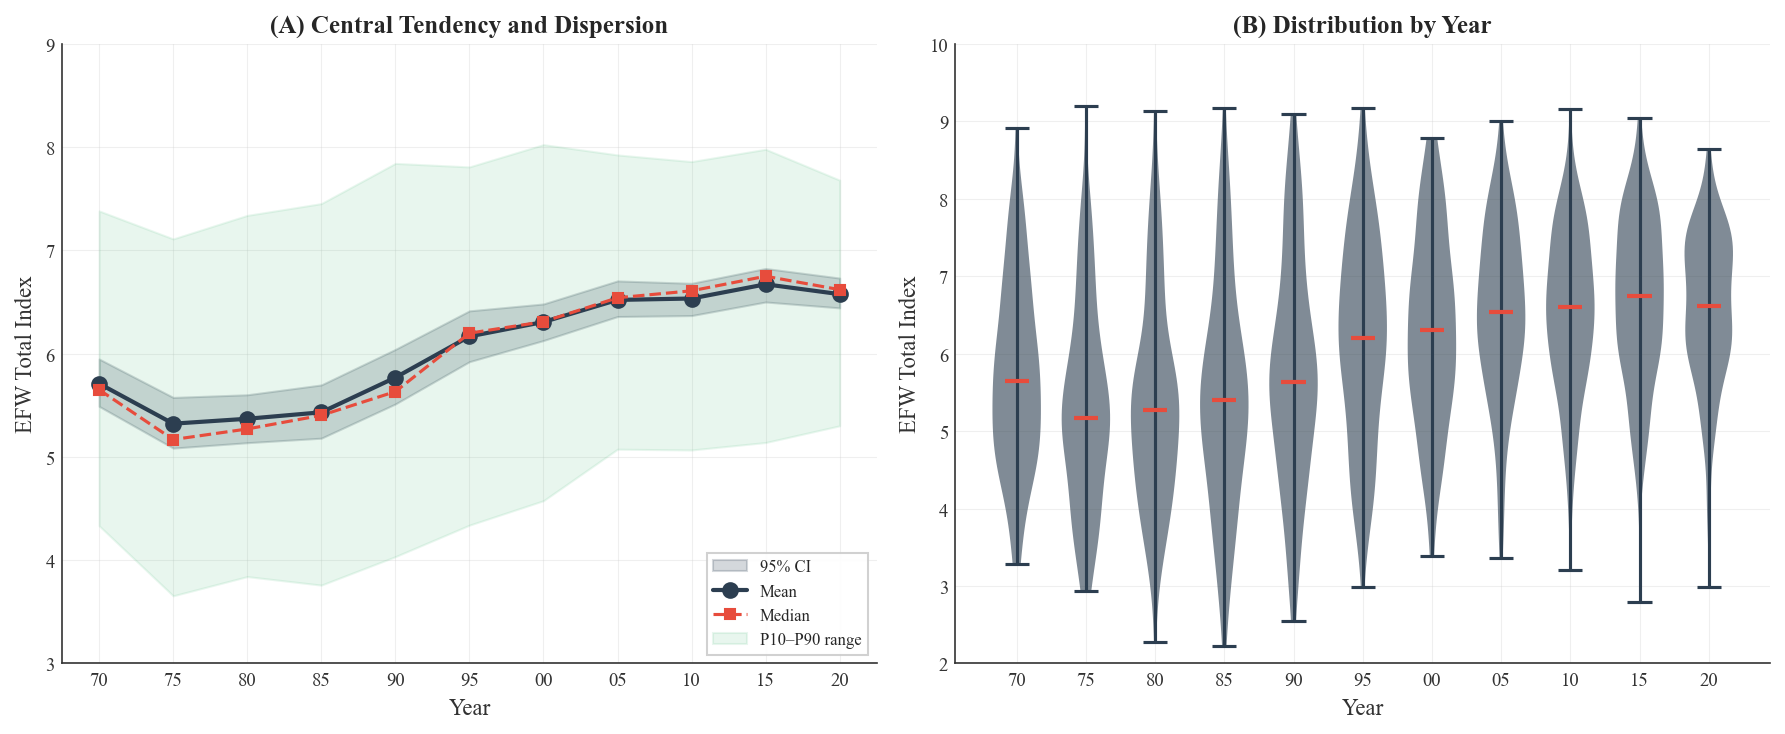


Figure 2: Global EFW trends
Key observation: Mean EFW increased from ~5.3 (1970) to ~6.8 (2000), then stabilized.


In [88]:
# =============================================================================
# SECTION I: EFW LEVELS — CROSS-SECTIONAL AND TEMPORAL PATTERNS
# =============================================================================

# -----------------------------------------------------------------------------
# I.1 Global Trends in EFW
# -----------------------------------------------------------------------------

# Compute yearly statistics with confidence intervals
def bootstrap_ci(s: pd.Series, stat_func: Callable = np.mean, n_boot: int = 1000, ci: float = 0.95) -> tuple:
    """Compute bootstrap confidence interval for a statistic."""
    s_clean = s.dropna()
    if len(s_clean) < 10:
        return (np.nan, np.nan)
    
    boot_stats = []
    for _ in range(n_boot):
        boot_sample = np.random.choice(s_clean, size=len(s_clean), replace=True)
        boot_stats.append(stat_func(boot_sample))
    
    alpha = 1 - ci
    return (np.percentile(boot_stats, 100 * alpha / 2), np.percentile(boot_stats, 100 * (1 - alpha / 2)))


# Year-level summary with CIs
year_stats = []
for year, g in panel.groupby('year'):
    efw = g['efw_total'].dropna()
    if len(efw) >= 5:
        ci_low, ci_high = bootstrap_ci(efw, np.mean, n_boot=500)
        year_stats.append({
            'Year': int(year),
            'N': len(efw),
            'Mean': efw.mean(),
            'Median': efw.median(),
            'Std': efw.std(),
            'CI_low': ci_low,
            'CI_high': ci_high,
            'P10': efw.quantile(0.10),
            'P90': efw.quantile(0.90),
        })

year_stats_df = pd.DataFrame(year_stats)
save_table(year_stats_df, 'table5_efw_by_year')
show_table(year_stats_df, title="Table 5: EFW Total by Year — Summary Statistics")

# Figure 2: Global EFW Trends
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: Mean with confidence interval
ax1 = axes[0]
ax1.fill_between(year_stats_df['Year'], year_stats_df['CI_low'], year_stats_df['CI_high'], 
                  alpha=0.2, color=PALETTE['primary'], label='95% CI')
ax1.plot(year_stats_df['Year'], year_stats_df['Mean'], 
         marker='o', color=PALETTE['primary'], linewidth=2, markersize=7, label='Mean')
ax1.plot(year_stats_df['Year'], year_stats_df['Median'], 
         marker='s', color=PALETTE['secondary'], linewidth=1.5, markersize=5, 
         linestyle='--', label='Median')
ax1.fill_between(year_stats_df['Year'], year_stats_df['P10'], year_stats_df['P90'], 
                  alpha=0.1, color=PALETTE['tertiary'], label='P10–P90 range')

ax1.set_xlabel('Year')
ax1.set_ylabel('EFW Total Index')
ax1.set_title('(A) Central Tendency and Dispersion', fontweight='bold')
ax1.legend(loc='lower right', fontsize=8)
ax1.set_ylim(3, 9)
ax1.set_xticks(QUINQUENNIAL_YEARS)
ax1.set_xticklabels([str(y)[-2:] for y in QUINQUENNIAL_YEARS])

# Panel B: Distribution evolution (violin/box hybrid)
ax2 = axes[1]
data_for_violin = [panel[panel['year'] == y]['efw_total'].dropna() for y in QUINQUENNIAL_YEARS]
positions = range(len(QUINQUENNIAL_YEARS))

parts = ax2.violinplot(data_for_violin, positions=positions, showmeans=False, showmedians=True, widths=0.7)
for pc in parts['bodies']:
    pc.set_facecolor(PALETTE['primary'])
    pc.set_alpha(0.6)
parts['cmedians'].set_color(PALETTE['secondary'])
parts['cmedians'].set_linewidth(2)

ax2.set_xlabel('Year')
ax2.set_ylabel('EFW Total Index')
ax2.set_title('(B) Distribution by Year', fontweight='bold')
ax2.set_xticks(positions)
ax2.set_xticklabels([str(y)[-2:] for y in QUINQUENNIAL_YEARS])
ax2.set_ylim(2, 10)

plt.tight_layout()
save_fig('fig2_efw_global_trends')
plt.show()

print("\nFigure 2: Global EFW trends")
print("Key observation: Mean EFW increased from ~5.3 (1970) to ~6.8 (2000), then stabilized.")

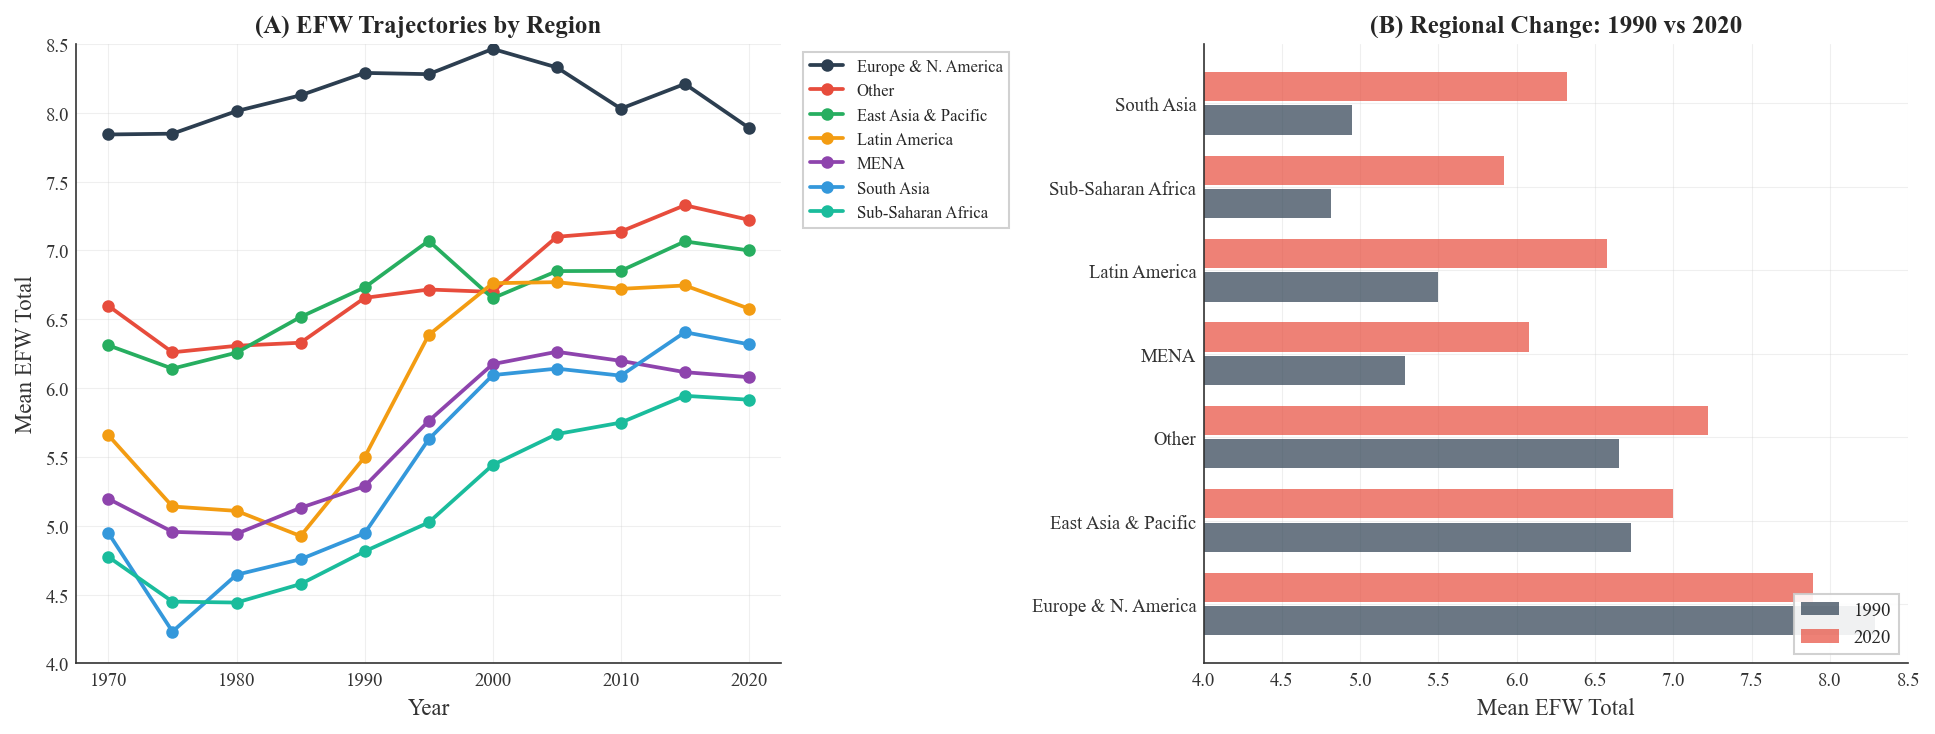

In [89]:
# -----------------------------------------------------------------------------
# I.2 EFW by Region and Income Group
# -----------------------------------------------------------------------------

# Regional trends
region_stats = (panel.dropna(subset=['efw_total'])
    .groupby(['continent', 'year'])
    .agg(
        mean_efw=('efw_total', 'mean'),
        median_efw=('efw_total', 'median'),
        std_efw=('efw_total', 'std'),
        n=('efw_total', 'count')
    )
    .reset_index()
)
save_table(region_stats, 'table6_efw_by_region_year')

# Figure 3: EFW by Region
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: Regional trajectories
ax1 = axes[0]
regions_ordered = region_stats.groupby('continent')['mean_efw'].mean().sort_values(ascending=False).index

for i, region in enumerate(regions_ordered):
    g = region_stats[region_stats['continent'] == region]
    ax1.plot(g['year'], g['mean_efw'], marker='o', markersize=5, 
             label=region, color=CATEGORY_COLORS[i % len(CATEGORY_COLORS)], linewidth=1.8)

ax1.set_xlabel('Year')
ax1.set_ylabel('Mean EFW Total')
ax1.set_title('(A) EFW Trajectories by Region', fontweight='bold')
ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax1.set_ylim(4, 8.5)
ax1.set_xticks(QUINQUENNIAL_YEARS[::2])

# Panel B: Regional comparison (2020 vs 1990)
ax2 = axes[1]
comparison_years = [1990, 2020]
comp_data = region_stats[region_stats['year'].isin(comparison_years)].pivot(
    index='continent', columns='year', values='mean_efw'
).dropna()

if 1990 in comp_data.columns and 2020 in comp_data.columns:
    comp_data['change'] = comp_data[2020] - comp_data[1990]
    comp_data = comp_data.sort_values('change', ascending=True)
    
    y_pos = range(len(comp_data))
    
    # Plot 1990 and 2020 values
    ax2.barh([y - 0.2 for y in y_pos], comp_data[1990], height=0.35, 
             color=PALETTE['primary'], alpha=0.7, label='1990')
    ax2.barh([y + 0.2 for y in y_pos], comp_data[2020], height=0.35, 
             color=PALETTE['secondary'], alpha=0.7, label='2020')
    
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(comp_data.index)
    ax2.set_xlabel('Mean EFW Total')
    ax2.set_title('(B) Regional Change: 1990 vs 2020', fontweight='bold')
    ax2.legend(loc='lower right')
    ax2.set_xlim(4, 8.5)

plt.tight_layout()
save_fig('fig3_efw_by_region')
plt.show()

# Income group analysis
income_stats = (panel.dropna(subset=['efw_total'])
    .groupby(['wb_income_simple', 'year'])
    .agg(
        mean_efw=('efw_total', 'mean'),
        median_efw=('efw_total', 'median'),
        std_efw=('efw_total', 'std'),
        n=('efw_total', 'count')
    )
    .reset_index()
)
save_table(income_stats, 'table7_efw_by_income_year')

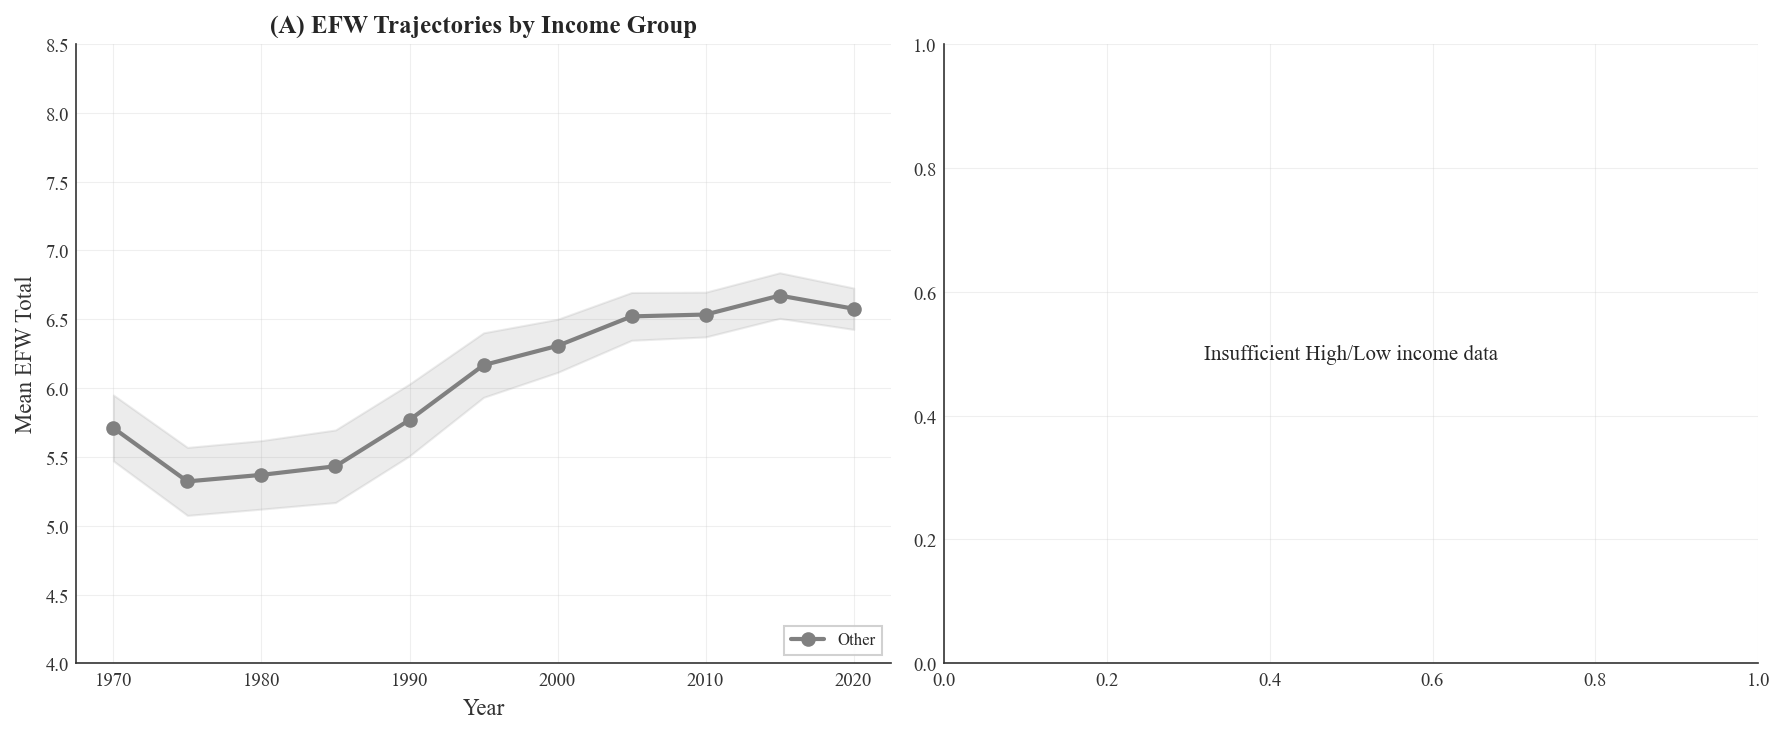


Figure 4: EFW by income group
Key finding: The EFW gap between high and low income countries has been relatively stable,
suggesting persistent structural differences in economic freedom across development levels.


In [90]:
# -----------------------------------------------------------------------------
# I.3 Income Group Analysis
# -----------------------------------------------------------------------------

# Figure 4: EFW by Income Group
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: Income group trajectories
ax1 = axes[0]
income_order_plot = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']
income_colors = {
    'Low income': PALETTE['secondary'],
    'Lower middle income': PALETTE['quaternary'],
    'Upper middle income': PALETTE['tertiary'],
    'High income': PALETTE['primary'],
}

# Use only groups with data to avoid empty plots
available_groups = [g for g in income_order_plot if g in income_stats['wb_income_simple'].unique()]
if not available_groups:
    available_groups = [g for g in income_stats['wb_income_simple'].dropna().unique()]

if not available_groups:
    ax1.text(0.5, 0.5, 'No income-group data available', ha='center', va='center', transform=ax1.transAxes)

for income in available_groups:
    g = income_stats[income_stats['wb_income_simple'] == income]
    if not g.empty:
        ax1.plot(g['year'], g['mean_efw'], marker='o', markersize=6, 
                 label=income, color=income_colors.get(income, 'gray'), linewidth=2)
        # Add confidence band (using std/sqrt(n) approximation)
        if 'std_efw' in g.columns and 'n' in g.columns:
            se = g['std_efw'] / np.sqrt(g['n'])
            ax1.fill_between(g['year'], g['mean_efw'] - 1.96*se, g['mean_efw'] + 1.96*se, 
                            alpha=0.15, color=income_colors.get(income, 'gray'))

ax1.set_xlabel('Year')
ax1.set_ylabel('Mean EFW Total')
ax1.set_title('(A) EFW Trajectories by Income Group', fontweight='bold')
ax1.legend(loc='lower right', fontsize=8)
ax1.set_ylim(4, 8.5)
ax1.set_xticks(QUINQUENNIAL_YEARS[::2])

# Panel B: Gap analysis
ax2 = axes[1]
# Calculate gap between high and low income
gap_data = []
for year in QUINQUENNIAL_YEARS:
    yr_data = income_stats[income_stats['year'] == year]
    high = yr_data[yr_data['wb_income_simple'] == 'High income']['mean_efw'].values
    low = yr_data[yr_data['wb_income_simple'] == 'Low income']['mean_efw'].values
    if len(high) > 0 and len(low) > 0:
        gap_data.append({'Year': year, 'Gap (High - Low)': high[0] - low[0]})

gap_df = pd.DataFrame(gap_data)
if not gap_df.empty:
    ax2.bar(gap_df['Year'], gap_df['Gap (High - Low)'], 
            color=PALETTE['quinary'], alpha=0.7, width=4, edgecolor='white')
    ax2.axhline(gap_df['Gap (High - Low)'].mean(), color=PALETTE['dark_gray'], 
                linestyle='--', linewidth=1.5, label=f"Mean gap: {gap_df['Gap (High - Low)'].mean():.2f}")
    ax2.set_xlabel('Year')
    ax2.set_ylabel('EFW Gap (High income − Low income)')
    ax2.set_title('(B) Income Gap in Economic Freedom', fontweight='bold')
    ax2.legend(loc='upper right')
    ax2.set_xticks(QUINQUENNIAL_YEARS)
    ax2.set_xticklabels([str(y)[-2:] for y in QUINQUENNIAL_YEARS])
    save_table(gap_df, 'table8_income_efw_gap')
else:
    ax2.text(0.5, 0.5, 'Insufficient High/Low income data', ha='center', va='center', transform=ax2.transAxes)

plt.tight_layout()
save_fig('fig4_efw_by_income')
plt.show()

print("\nFigure 4: EFW by income group")
print("Key finding: The EFW gap between high and low income countries has been relatively stable,"
      "\nsuggesting persistent structural differences in economic freedom across development levels.")


---

## Section II: Magnitude Analysis of EFW Changes

This section provides a rigorous examination of the **magnitudes** of EFW changes over 5-year intervals. We analyze not just whether EFW changes, but *how much* it changes and under what conditions. Understanding magnitudes is critical for policy evaluation and for assessing the practical significance of observed correlations.

Observations with valid 5-year EFW changes: 1,301


**Table 9: EFW 5-Year Change — Distributional Statistics**

,Statistic,Value
0,Variable,EFW 5-Year Change
1,N,1301
2,Mean,0.126221
3,Std. Dev.,0.502483
4,Min,-1.938385
5,P5,-0.662476
6,P10,-0.399533
7,P25,-0.149595
8,Median,0.084989
9,P75,0.377233


**Table 10: Share of Observations Exceeding Magnitude Thresholds**

,Threshold,Share,Count
0,|Δ| ≥ 0.25,0.523,680
1,|Δ| ≥ 0.5,0.251,326
2,|Δ| ≥ 1.0,0.065,85
3,|Δ| ≥ 1.5,0.014,18
4,|Δ| ≥ 2.0,0.002,2


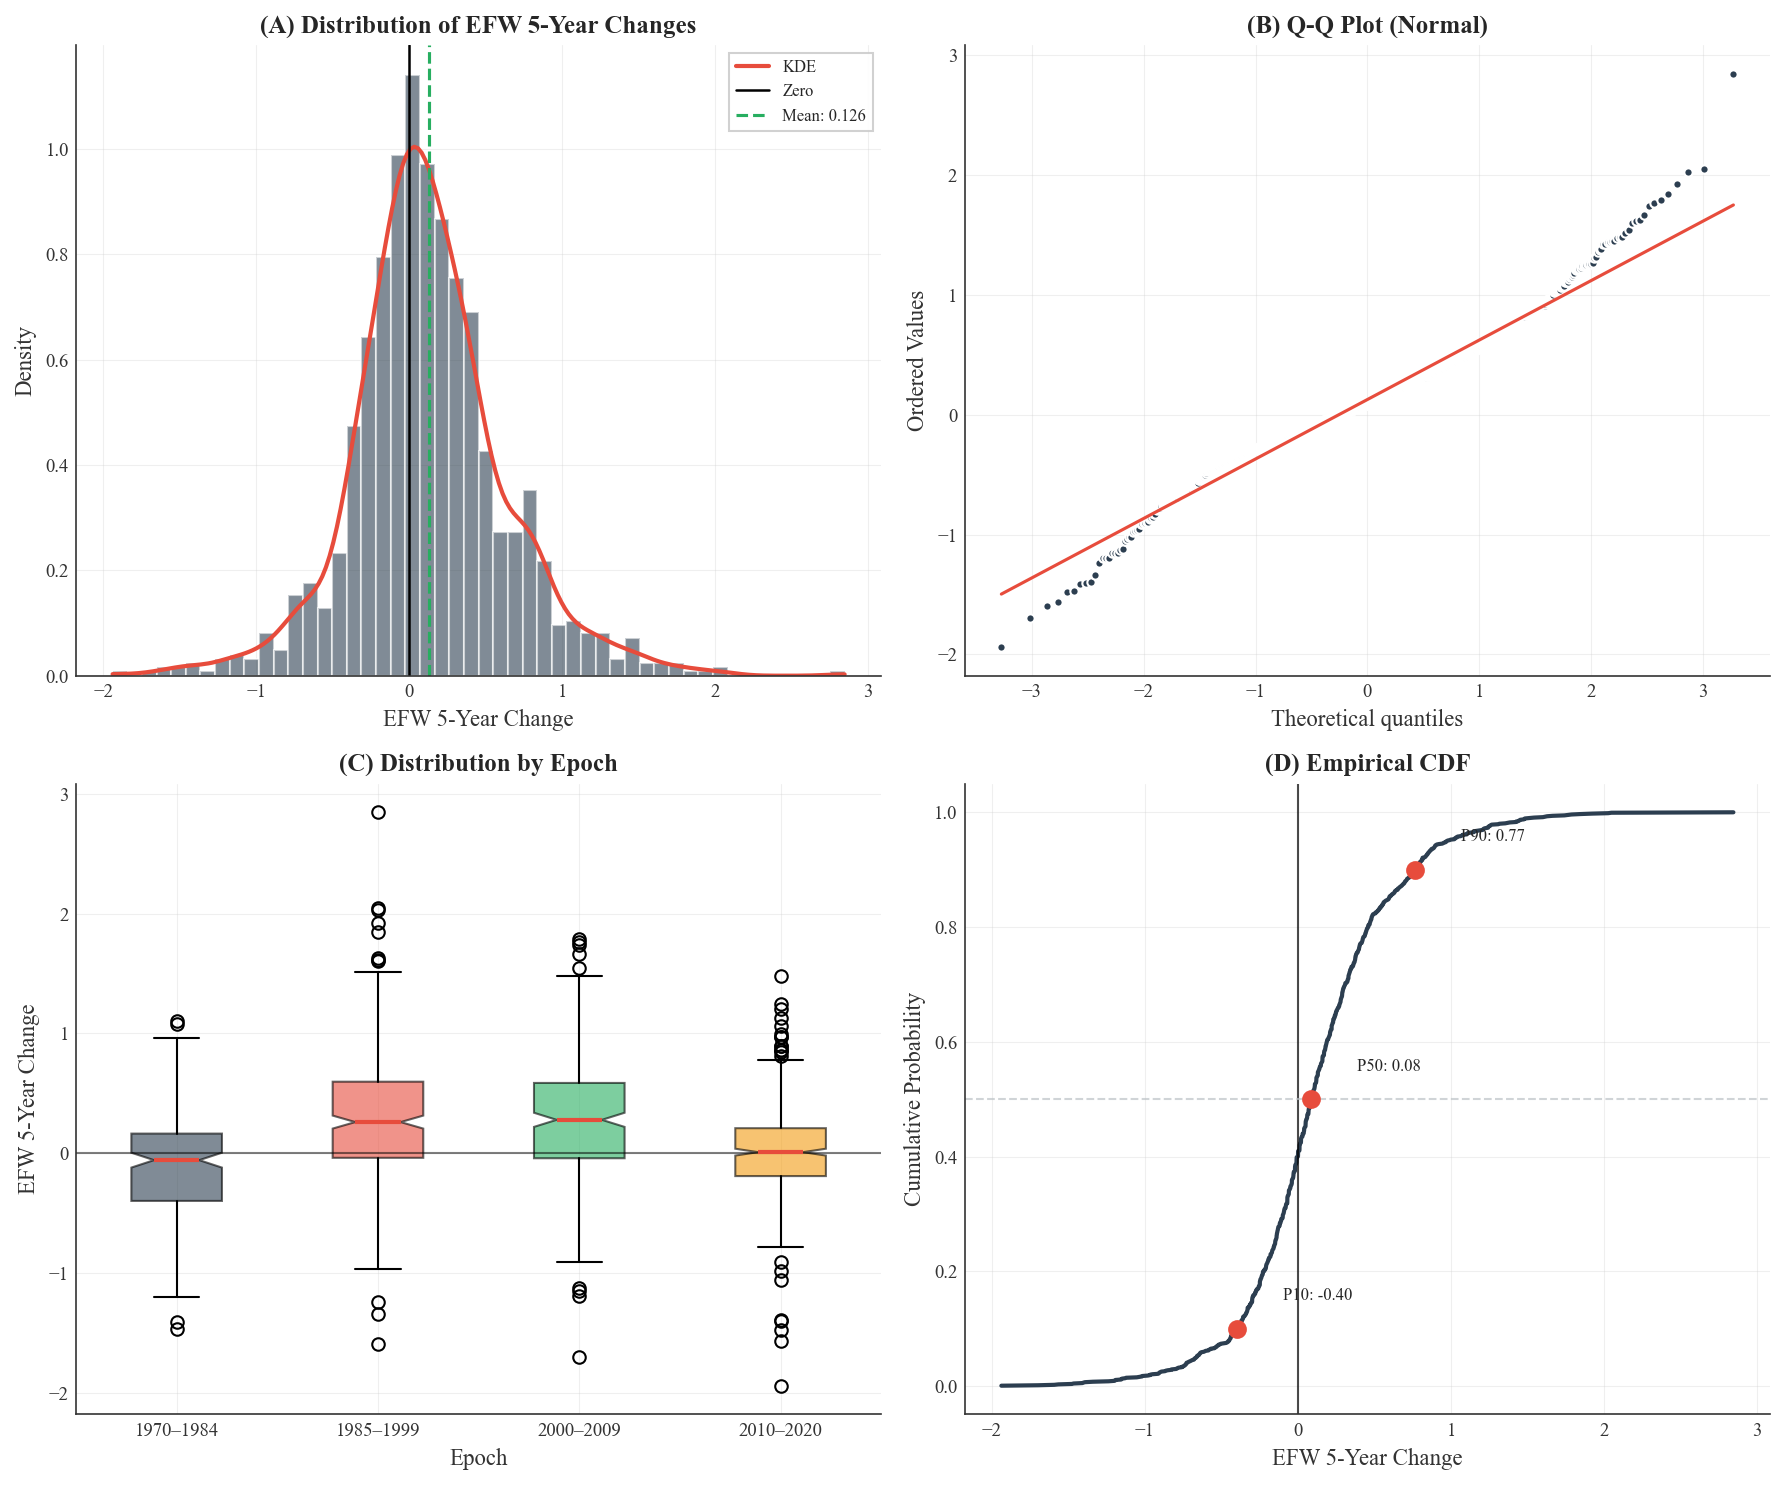


Figure 5: Distribution of EFW 5-year changes
Key findings:
  - Mean change: 0.126, Median: 0.085
  - Standard deviation: 0.502
  - Skewness: 0.309 (slightly right-skewed)
  - Share of changes > 1 point: 6.5%


In [91]:
# =============================================================================
# SECTION II: MAGNITUDE ANALYSIS OF EFW CHANGES
# =============================================================================

# Filter to observations with valid 5-year changes
change_df = panel.dropna(subset=['efw_delta_5y']).copy()
print(f"Observations with valid 5-year EFW changes: {len(change_df):,}")

# -----------------------------------------------------------------------------
# II.1 Overall Distribution of EFW Changes
# -----------------------------------------------------------------------------

# Comprehensive statistics
change_stats = compute_distribution_stats(change_df['efw_delta_5y'], 'EFW 5-Year Change')
show_table(change_stats.T.reset_index().rename(columns={'index': 'Statistic', 0: 'Value'}),
           title="Table 9: EFW 5-Year Change — Distributional Statistics")
save_table(change_stats, 'table9_efw_change_distribution')

# Key magnitude thresholds
thresholds = [0.25, 0.5, 1.0, 1.5, 2.0]
magnitude_shares = []
for thresh in thresholds:
    share = (change_df['efw_delta_5y'].abs() >= thresh).mean()
    magnitude_shares.append({'Threshold': f'|Δ| ≥ {thresh}', 'Share': share, 'Count': int(share * len(change_df))})

magnitude_df = pd.DataFrame(magnitude_shares)
show_table(magnitude_df, title="Table 10: Share of Observations Exceeding Magnitude Thresholds")
save_table(magnitude_df, 'table10_efw_change_magnitude_thresholds')

# Figure 5: Distribution of EFW Changes
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Panel A: Histogram with KDE
ax1 = axes[0, 0]
changes = change_df['efw_delta_5y'].dropna()
n_bins = 50
counts, bins, patches = ax1.hist(changes, bins=n_bins, density=True, 
                                  color=PALETTE['primary'], alpha=0.6, edgecolor='white')

# Add KDE
from scipy.stats import gaussian_kde
kde = gaussian_kde(changes)
x_kde = np.linspace(changes.min(), changes.max(), 200)
ax1.plot(x_kde, kde(x_kde), color=PALETTE['secondary'], linewidth=2, label='KDE')

# Mark zero and mean
ax1.axvline(0, color='black', linewidth=1.2, linestyle='-', label='Zero')
ax1.axvline(changes.mean(), color=PALETTE['tertiary'], linewidth=1.5, linestyle='--', 
            label=f'Mean: {changes.mean():.3f}')

ax1.set_xlabel('EFW 5-Year Change')
ax1.set_ylabel('Density')
ax1.set_title('(A) Distribution of EFW 5-Year Changes', fontweight='bold')
ax1.legend(loc='upper right', fontsize=8)

# Panel B: QQ plot (normality check)
ax2 = axes[0, 1]
stats.probplot(changes, dist="norm", plot=ax2)
ax2.get_lines()[0].set_markerfacecolor(PALETTE['primary'])
ax2.get_lines()[0].set_markeredgecolor('white')
ax2.get_lines()[0].set_markersize(4)
ax2.get_lines()[1].set_color(PALETTE['secondary'])
ax2.set_title('(B) Q-Q Plot (Normal)', fontweight='bold')

# Panel C: Box plot by epoch
ax3 = axes[1, 0]
epoch_order = EPOCH_LABELS
epoch_data = [change_df[change_df['epoch'] == ep]['efw_delta_5y'].dropna() for ep in epoch_order]

bp = ax3.boxplot(epoch_data, labels=epoch_order, patch_artist=True, 
                  notch=True, medianprops=dict(color=PALETTE['secondary'], linewidth=2))
for patch, color in zip(bp['boxes'], CATEGORY_COLORS[:len(epoch_order)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax3.axhline(0, color='black', linewidth=1, linestyle='-', alpha=0.5)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('EFW 5-Year Change')
ax3.set_title('(C) Distribution by Epoch', fontweight='bold')

# Panel D: Cumulative distribution
ax4 = axes[1, 1]
sorted_changes = np.sort(changes)
cumulative = np.arange(1, len(sorted_changes) + 1) / len(sorted_changes)
ax4.plot(sorted_changes, cumulative, color=PALETTE['primary'], linewidth=2)
ax4.axvline(0, color='black', linewidth=1, linestyle='-', alpha=0.7)
ax4.axhline(0.5, color=PALETTE['light_gray'], linewidth=1, linestyle='--', alpha=0.7)

# Mark key quantiles
for q, label in [(0.1, 'P10'), (0.5, 'P50'), (0.9, 'P90')]:
    val = np.percentile(sorted_changes, 100*q)
    ax4.plot(val, q, 'o', color=PALETTE['secondary'], markersize=8)
    ax4.annotate(f'{label}: {val:.2f}', xy=(val, q), xytext=(val + 0.3, q + 0.05), fontsize=8)

ax4.set_xlabel('EFW 5-Year Change')
ax4.set_ylabel('Cumulative Probability')
ax4.set_title('(D) Empirical CDF', fontweight='bold')

plt.tight_layout()
save_fig('fig5_efw_change_distribution')
plt.show()

print("\nFigure 5: Distribution of EFW 5-year changes")
print(f"Key findings:")
print(f"  - Mean change: {changes.mean():.3f}, Median: {changes.median():.3f}")
print(f"  - Standard deviation: {changes.std():.3f}")
print(f"  - Skewness: {skew(changes):.3f} (slightly {'right' if skew(changes) > 0 else 'left'}-skewed)")
print(f"  - Share of changes > 1 point: {(changes.abs() > 1).mean()*100:.1f}%")

**Table 11: EFW 5-Year Change Statistics by Epoch**

,Epoch,N,Mean,Median,Std,P10,P90,Share Positive,Mean Positive,Mean Negative
0,1970–1984,202,-0.122,-0.057,0.476,-0.745,0.405,0.421,0.293,-0.431
1,1985–1999,338,0.290,0.261,0.568,-0.319,0.992,0.716,0.536,-0.337
2,2000–2009,279,0.290,0.280,0.515,-0.238,0.861,0.706,0.519,-0.262
3,2010–2020,482,0.021,0.010,0.370,-0.360,0.436,0.517,0.277,-0.255


**Table 12: EFW 5-Year Change Statistics by Region**

,Region,N,Mean,Median,Std,P10,P90,Share Positive
4,Other,341,0.188,0.110,0.454,-0.290,0.774,0.642
5,South Asia,43,0.183,0.223,0.358,-0.281,0.594,0.651
6,Sub-Saharan Africa,332,0.128,0.128,0.524,-0.411,0.783,0.593
0,East Asia & Pacific,159,0.110,0.080,0.410,-0.337,0.596,0.616
2,Latin America,246,0.086,0.040,0.627,-0.679,0.854,0.524
3,MENA,160,0.070,0.051,0.471,-0.448,0.618,0.562
1,Europe & N. America,20,0.005,0.104,0.209,-0.301,0.187,0.600


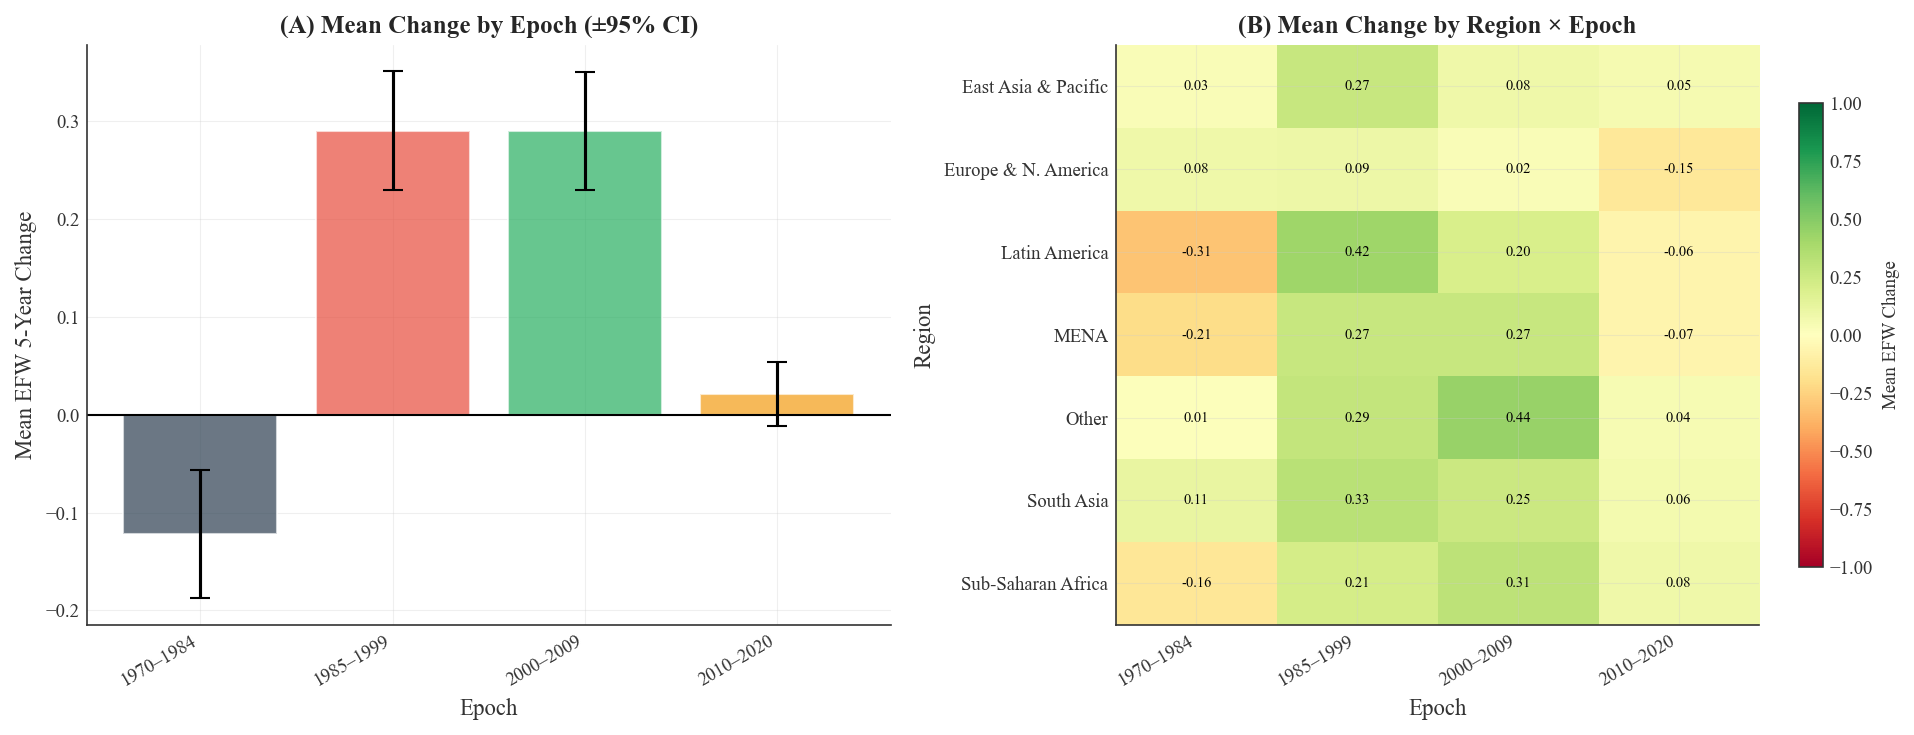

In [92]:
# -----------------------------------------------------------------------------
# II.2 Conditional Heterogeneity in Magnitudes
# -----------------------------------------------------------------------------

# By epoch
epoch_change_stats = []
for epoch, g in change_df.groupby('epoch'):
    s = g['efw_delta_5y'].dropna()
    if len(s) >= 10:
        epoch_change_stats.append({
            'Epoch': str(epoch),
            'N': len(s),
            'Mean': s.mean(),
            'Median': s.median(),
            'Std': s.std(),
            'P10': s.quantile(0.10),
            'P90': s.quantile(0.90),
            'Share Positive': (s > 0).mean(),
            'Mean Positive': s[s > 0].mean() if (s > 0).any() else np.nan,
            'Mean Negative': s[s < 0].mean() if (s < 0).any() else np.nan,
        })

epoch_change_df = pd.DataFrame(epoch_change_stats)
show_table(epoch_change_df, title="Table 11: EFW 5-Year Change Statistics by Epoch")
save_table(epoch_change_df, 'table11_efw_change_by_epoch')

# By region
region_change_stats = []
for region, g in change_df.groupby('continent'):
    s = g['efw_delta_5y'].dropna()
    if len(s) >= 10:
        region_change_stats.append({
            'Region': region,
            'N': len(s),
            'Mean': s.mean(),
            'Median': s.median(),
            'Std': s.std(),
            'P10': s.quantile(0.10),
            'P90': s.quantile(0.90),
            'Share Positive': (s > 0).mean(),
        })

region_change_df = pd.DataFrame(region_change_stats).sort_values('Mean', ascending=False)
show_table(region_change_df, title="Table 12: EFW 5-Year Change Statistics by Region")
save_table(region_change_df, 'table12_efw_change_by_region')

# Figure 6: Magnitude Heterogeneity
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: Mean change by epoch with error bars
ax1 = axes[0]
x_pos = range(len(epoch_change_df))
means = epoch_change_df['Mean'].values
stds = epoch_change_df['Std'].values
ns = epoch_change_df['N'].values
se = stds / np.sqrt(ns)

ax1.bar(x_pos, means, yerr=1.96*se, capsize=5, color=CATEGORY_COLORS[:len(x_pos)], 
        alpha=0.7, edgecolor='white', error_kw={'linewidth': 1.5})
ax1.axhline(0, color='black', linewidth=1, linestyle='-')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(epoch_change_df['Epoch'], rotation=30, ha='right')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Mean EFW 5-Year Change')
ax1.set_title('(A) Mean Change by Epoch (±95% CI)', fontweight='bold')

# Panel B: Heatmap of mean change by region and epoch
ax2 = axes[1]
heatmap_data = change_df.groupby(['continent', 'epoch'])['efw_delta_5y'].mean().unstack()

if not heatmap_data.empty:
    im = ax2.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=1)
    ax2.set_xticks(range(len(heatmap_data.columns)))
    ax2.set_xticklabels([str(c) for c in heatmap_data.columns], rotation=30, ha='right')
    ax2.set_yticks(range(len(heatmap_data.index)))
    ax2.set_yticklabels(heatmap_data.index)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Region')
    ax2.set_title('(B) Mean Change by Region × Epoch', fontweight='bold')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax2, shrink=0.8)
    cbar.set_label('Mean EFW Change', fontsize=9)
    
    # Add text annotations
    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            val = heatmap_data.iloc[i, j]
            if pd.notna(val):
                text_color = 'white' if abs(val) > 0.5 else 'black'
                ax2.text(j, i, f'{val:.2f}', ha='center', va='center', 
                        fontsize=7, color=text_color)

plt.tight_layout()
save_fig('fig6_efw_change_heterogeneity')
plt.show()

# Save heatmap data
if not heatmap_data.empty:
    save_table(heatmap_data.reset_index(), 'table13_efw_change_region_epoch_matrix')

---

## Section III: Asymmetry Analysis

A critical question in institutional economics is whether gains and losses in economic freedom are symmetric. This section examines:

1. **Directional asymmetry**: Are positive and negative changes equally likely?
2. **Magnitude asymmetry**: Are positive and negative changes of equal size?
3. **Persistence asymmetry**: Do gains persist differently than losses?

These asymmetries have important implications for understanding reform processes.

**Table 14: Asymmetry Analysis — Increases vs Decreases**

,Direction,N,Share,Mean |Δ|,Median |Δ|,Mean Δ,Std |Δ|,P90 |Δ|
0,Increase,773,0.594,0.422,0.318,0.422,0.380,0.894
1,Decrease,522,0.401,0.310,0.220,-0.310,0.309,0.727
2,No change,6,0.005,0.000,0.000,0.000,0.000,0.000


**Table 31: Asymmetry by Initial EFW Quintile**

,Initial Quintile,N,Mean |Increase|,Mean |Decrease|,Difference (|Inc| - |Dec|),Mann-Whitney p
0,Q1 (Low),261,0.648,0.436,0.212,0.001
1,Q2,260,0.478,0.393,0.084,0.086
2,Q3,260,0.410,0.295,0.115,0.000
3,Q4,260,0.293,0.262,0.030,0.027
4,Q5 (High),260,0.188,0.227,-0.039,0.096



🔬 Statistical Tests for Magnitude Asymmetry:
   Mean |increase|: 0.422
   Mean |decrease|: 0.310
   Difference: 0.112
   Mann-Whitney U test p-value: 0.0000
   T-test p-value: 0.0000


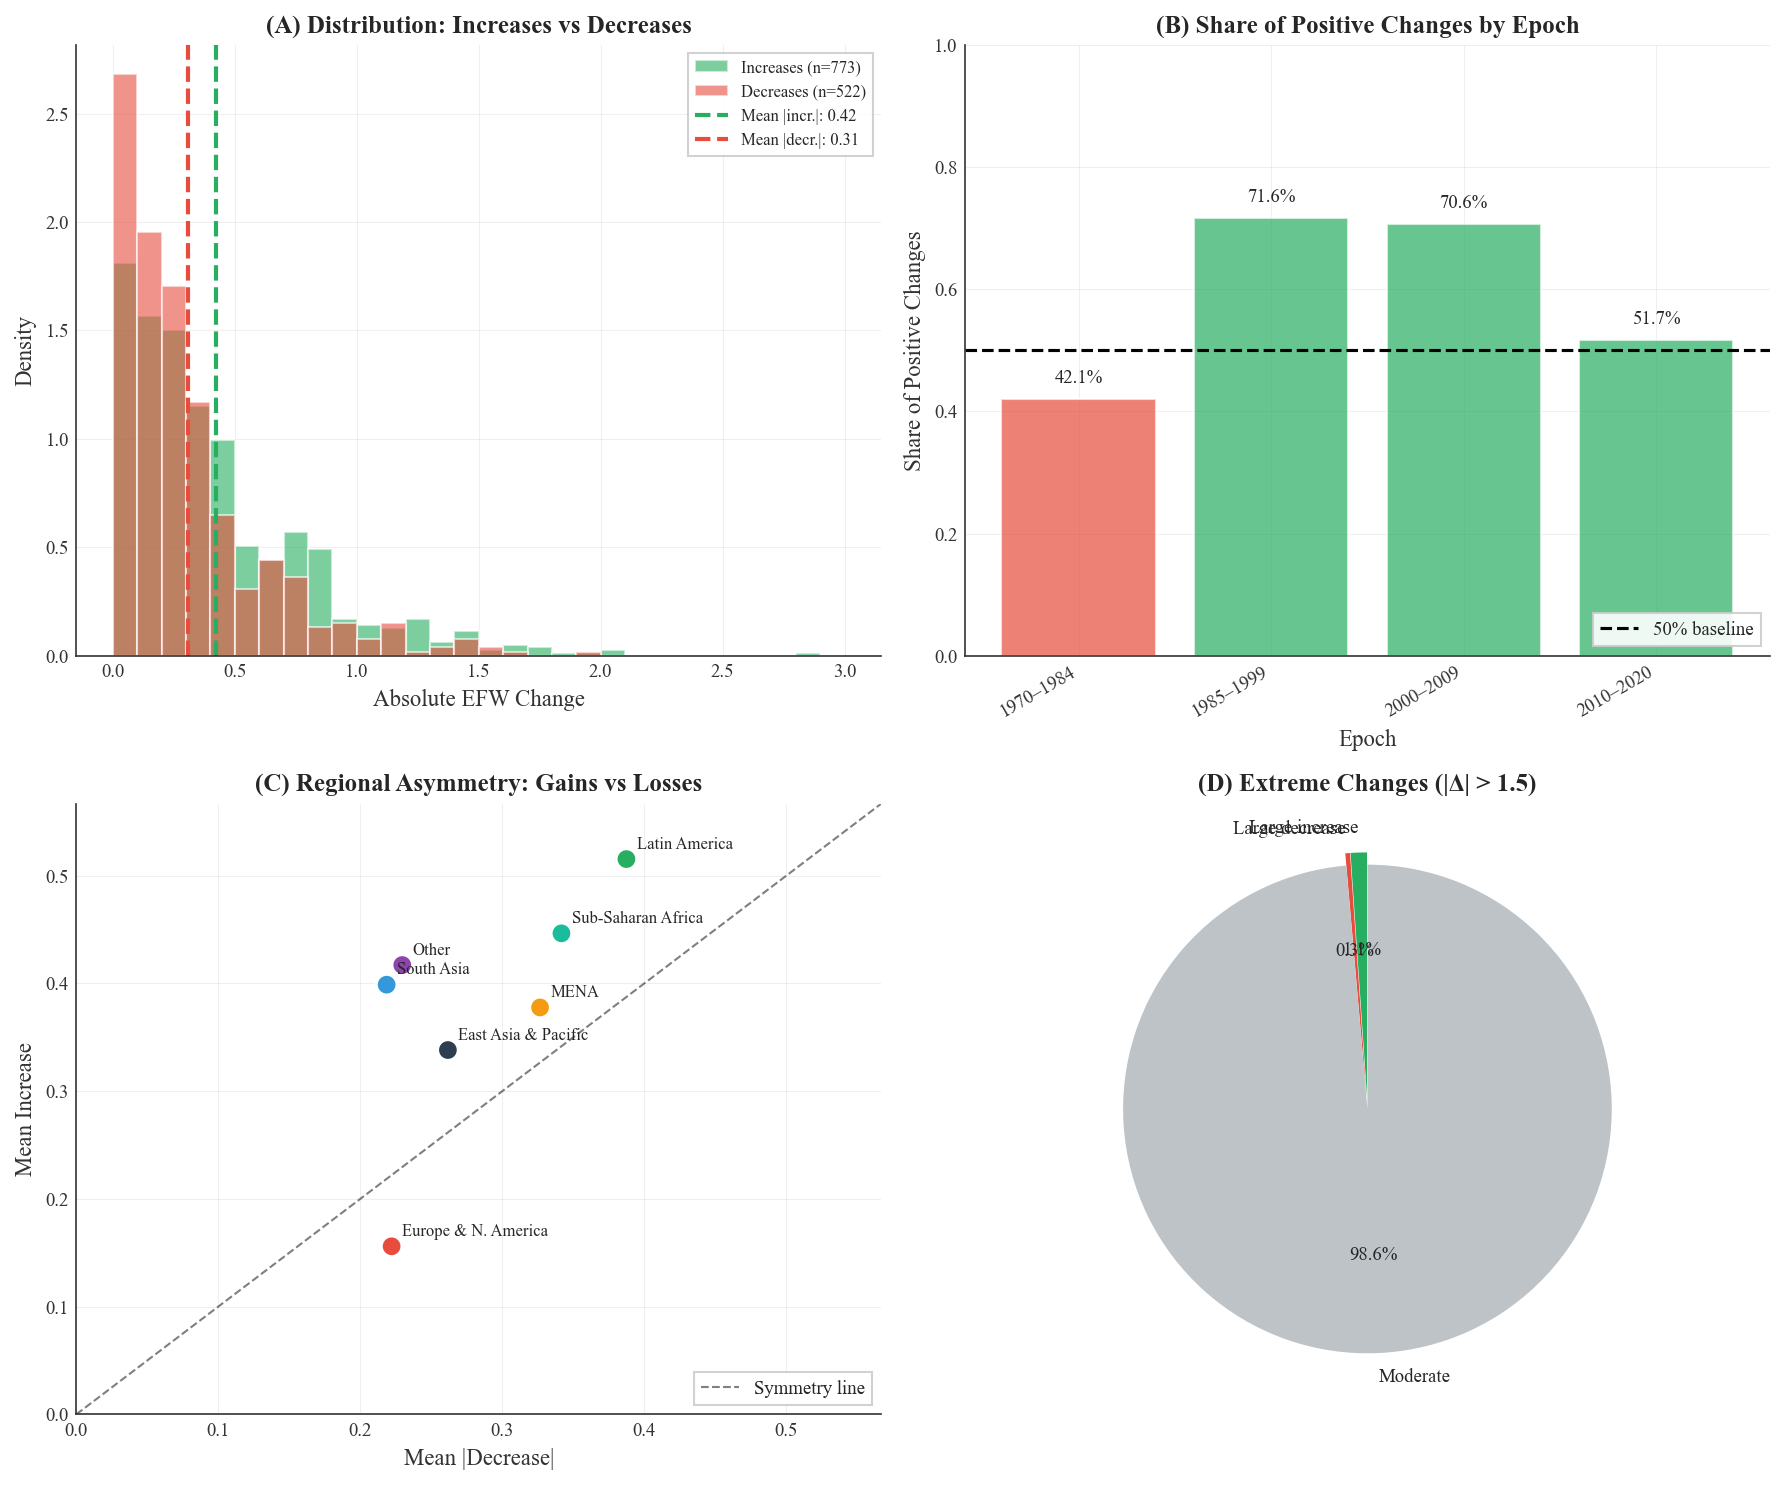


Figure 7: Asymmetry analysis
Key findings:
  - Share of positive changes: 59.4%
  - Extreme positive (Δ > 1.5): 1.1%
  - Extreme negative (Δ < -1.5): 0.3%


In [93]:
# =============================================================================
# SECTION III: ASYMMETRY ANALYSIS
# =============================================================================

# -----------------------------------------------------------------------------
# III.1 Directional and Magnitude Asymmetry
# -----------------------------------------------------------------------------

# Classify changes by direction
change_df['direction'] = np.select(
    [change_df['efw_delta_5y'] > 0, change_df['efw_delta_5y'] < 0],
    ['Increase', 'Decrease'],
    default='No change'
)

# Compute asymmetry statistics
direction_stats = []
for direction in ['Increase', 'Decrease', 'No change']:
    subset = change_df[change_df['direction'] == direction]['efw_delta_5y']
    direction_stats.append({
        'Direction': direction,
        'N': len(subset),
        'Share': len(subset) / len(change_df),
        'Mean |Δ|': subset.abs().mean(),
        'Median |Δ|': subset.abs().median(),
        'Mean Δ': subset.mean(),
        'Std |Δ|': subset.abs().std(),
        'P90 |Δ|': subset.abs().quantile(0.90) if len(subset) > 0 else np.nan,
    })

direction_stats_df = pd.DataFrame(direction_stats)
show_table(direction_stats_df, title="Table 14: Asymmetry Analysis — Increases vs Decreases")
save_table(direction_stats_df, 'table14_efw_asymmetry')

# -----------------------------------------------------------------------------
# III.1b Asymmetry by Initial State (Quintiles)
# -----------------------------------------------------------------------------

state_asym = change_df.dropna(subset=['efw_total_lag5', 'efw_delta_5y']).copy()
state_asym['initial_quintile'] = qcut_ranked(
    state_asym['efw_total_lag5'], q=5,
    labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)']
)

quintile_asym = []
for q, g in state_asym.groupby('initial_quintile'):
    inc = g[g['efw_delta_5y'] > 0]['efw_delta_5y'].abs()
    dec = g[g['efw_delta_5y'] < 0]['efw_delta_5y'].abs()
    mw_p = np.nan
    if len(inc) >= 10 and len(dec) >= 10:
        _, mw_p = stats.mannwhitneyu(inc, dec, alternative='two-sided')
    quintile_asym.append({
        'Initial Quintile': str(q),
        'N': len(g),
        'Mean |Increase|': inc.mean(),
        'Mean |Decrease|': dec.mean(),
        'Difference (|Inc| - |Dec|)': inc.mean() - dec.mean(),
        'Mann-Whitney p': mw_p,
    })

quintile_asym_df = pd.DataFrame(quintile_asym)
show_table(quintile_asym_df, title='Table 31: Asymmetry by Initial EFW Quintile')
save_table(quintile_asym_df, 'table31_asymmetry_by_quintile')


# Statistical test for asymmetry
increases = change_df[change_df['direction'] == 'Increase']['efw_delta_5y'].abs()
decreases = change_df[change_df['direction'] == 'Decrease']['efw_delta_5y'].abs()

if len(increases) >= 10 and len(decreases) >= 10:
    # Mann-Whitney U test (non-parametric)
    mw_stat, mw_pval = stats.mannwhitneyu(increases, decreases, alternative='two-sided')
    # T-test (parametric)
    t_stat, t_pval = stats.ttest_ind(increases, decreases)
    
    print(f"\n🔬 Statistical Tests for Magnitude Asymmetry:")
    print(f"   Mean |increase|: {increases.mean():.3f}")
    print(f"   Mean |decrease|: {decreases.mean():.3f}")
    print(f"   Difference: {increases.mean() - decreases.mean():.3f}")
    print(f"   Mann-Whitney U test p-value: {mw_pval:.4f}")
    print(f"   T-test p-value: {t_pval:.4f}")

# Figure 7: Asymmetry Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Panel A: Mirrored histogram (increases vs decreases)
ax1 = axes[0, 0]
bins = np.linspace(0, 3, 31)

ax1.hist(increases, bins=bins, alpha=0.6, color=PALETTE['positive'], 
         label=f'Increases (n={len(increases)})', density=True, edgecolor='white')
ax1.hist(decreases, bins=bins, alpha=0.6, color=PALETTE['negative'], 
         label=f'Decreases (n={len(decreases)})', density=True, edgecolor='white')

ax1.axvline(increases.mean(), color=PALETTE['positive'], linestyle='--', linewidth=2, 
            label=f'Mean |incr.|: {increases.mean():.2f}')
ax1.axvline(decreases.mean(), color=PALETTE['negative'], linestyle='--', linewidth=2, 
            label=f'Mean |decr.|: {decreases.mean():.2f}')

ax1.set_xlabel('Absolute EFW Change')
ax1.set_ylabel('Density')
ax1.set_title('(A) Distribution: Increases vs Decreases', fontweight='bold')
ax1.legend(loc='upper right', fontsize=8)

# Panel B: Proportion of positive changes by epoch
ax2 = axes[0, 1]
pos_share = change_df.groupby('epoch')['efw_delta_5y'].apply(lambda s: (s > 0).mean()).reset_index()
pos_share.columns = ['Epoch', 'Share Positive']

colors = [PALETTE['positive'] if s > 0.5 else PALETTE['negative'] for s in pos_share['Share Positive']]
bars = ax2.bar(range(len(pos_share)), pos_share['Share Positive'], color=colors, alpha=0.7, edgecolor='white')
ax2.axhline(0.5, color='black', linestyle='--', linewidth=1.5, label='50% baseline')
ax2.set_xticks(range(len(pos_share)))
ax2.set_xticklabels(pos_share['Epoch'], rotation=30, ha='right')
ax2.set_ylabel('Share of Positive Changes')
ax2.set_xlabel('Epoch')
ax2.set_title('(B) Share of Positive Changes by Epoch', fontweight='bold')
ax2.set_ylim(0, 1)
ax2.legend(loc='lower right')

# Add value labels
for bar, val in zip(bars, pos_share['Share Positive']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{val:.1%}', ha='center', va='bottom', fontsize=9)

# Panel C: Scatter of positive vs negative magnitude by region
ax3 = axes[1, 0]
region_asym = change_df.groupby('continent').agg(
    mean_pos=('efw_delta_5y', lambda s: s[s > 0].mean() if (s > 0).any() else np.nan),
    mean_neg=('efw_delta_5y', lambda s: s[s < 0].abs().mean() if (s < 0).any() else np.nan),
).dropna()

ax3.scatter(region_asym['mean_neg'], region_asym['mean_pos'], 
            s=100, c=CATEGORY_COLORS[:len(region_asym)], edgecolor='white', linewidth=1.5)

# Add 45-degree line
max_val = max(region_asym['mean_neg'].max(), region_asym['mean_pos'].max()) * 1.1
ax3.plot([0, max_val], [0, max_val], 'k--', linewidth=1, alpha=0.5, label='Symmetry line')

# Label points
for i, (region, row) in enumerate(region_asym.iterrows()):
    ax3.annotate(region, (row['mean_neg'], row['mean_pos']), 
                 xytext=(5, 5), textcoords='offset points', fontsize=8)

ax3.set_xlabel('Mean |Decrease|')
ax3.set_ylabel('Mean Increase')
ax3.set_title('(C) Regional Asymmetry: Gains vs Losses', fontweight='bold')
ax3.legend(loc='lower right')
ax3.set_xlim(0, max_val)
ax3.set_ylim(0, max_val)

# Panel D: Tail analysis (extreme changes)
ax4 = axes[1, 1]

# Define extreme changes (|Δ| > 1.5)
extreme_threshold = 1.5
change_df['extreme'] = change_df['efw_delta_5y'].abs() > extreme_threshold
change_df['extreme_direction'] = np.where(
    change_df['efw_delta_5y'] > extreme_threshold, 'Large increase',
    np.where(change_df['efw_delta_5y'] < -extreme_threshold, 'Large decrease', 'Moderate')
)

extreme_counts = change_df['extreme_direction'].value_counts()
colors_extreme = [PALETTE['positive'], PALETTE['negative'], PALETTE['light_gray']]
labels_ordered = ['Large increase', 'Large decrease', 'Moderate']
counts_ordered = [extreme_counts.get(l, 0) for l in labels_ordered]

wedges, texts, autotexts = ax4.pie(counts_ordered, labels=labels_ordered, autopct='%1.1f%%',
                                    colors=colors_extreme, startangle=90, explode=(0.05, 0.05, 0),
                                    textprops={'fontsize': 9})
ax4.set_title(f'(D) Extreme Changes (|Δ| > {extreme_threshold})', fontweight='bold')

plt.tight_layout()
save_fig('fig7_asymmetry_analysis')
plt.show()

print(f"\nFigure 7: Asymmetry analysis")
print(f"Key findings:")
print(f"  - Share of positive changes: {(change_df['efw_delta_5y'] > 0).mean():.1%}")
print(f"  - Extreme positive (Δ > {extreme_threshold}): {(change_df['efw_delta_5y'] > extreme_threshold).mean():.1%}")
print(f"  - Extreme negative (Δ < -{extreme_threshold}): {(change_df['efw_delta_5y'] < -extreme_threshold).mean():.1%}")


**Table 15: Asymmetry by EFW Area**

,Area,N,Mean Δ,Share Positive,Mean |Increase|,Mean |Decrease|,Asymmetry Ratio
0,Area 1: Size of Government,1294,0.071,0.512,0.659,0.552,1.193
1,Area 2: Legal System,1301,0.067,0.579,0.291,0.242,1.203
2,Area 3: Sound Money,1301,0.182,0.557,1.060,0.940,1.127
3,Area 4: Trade Freedom,1124,0.204,0.544,0.845,0.568,1.486
4,Area 5: Regulation,1296,0.102,0.547,0.448,0.340,1.315


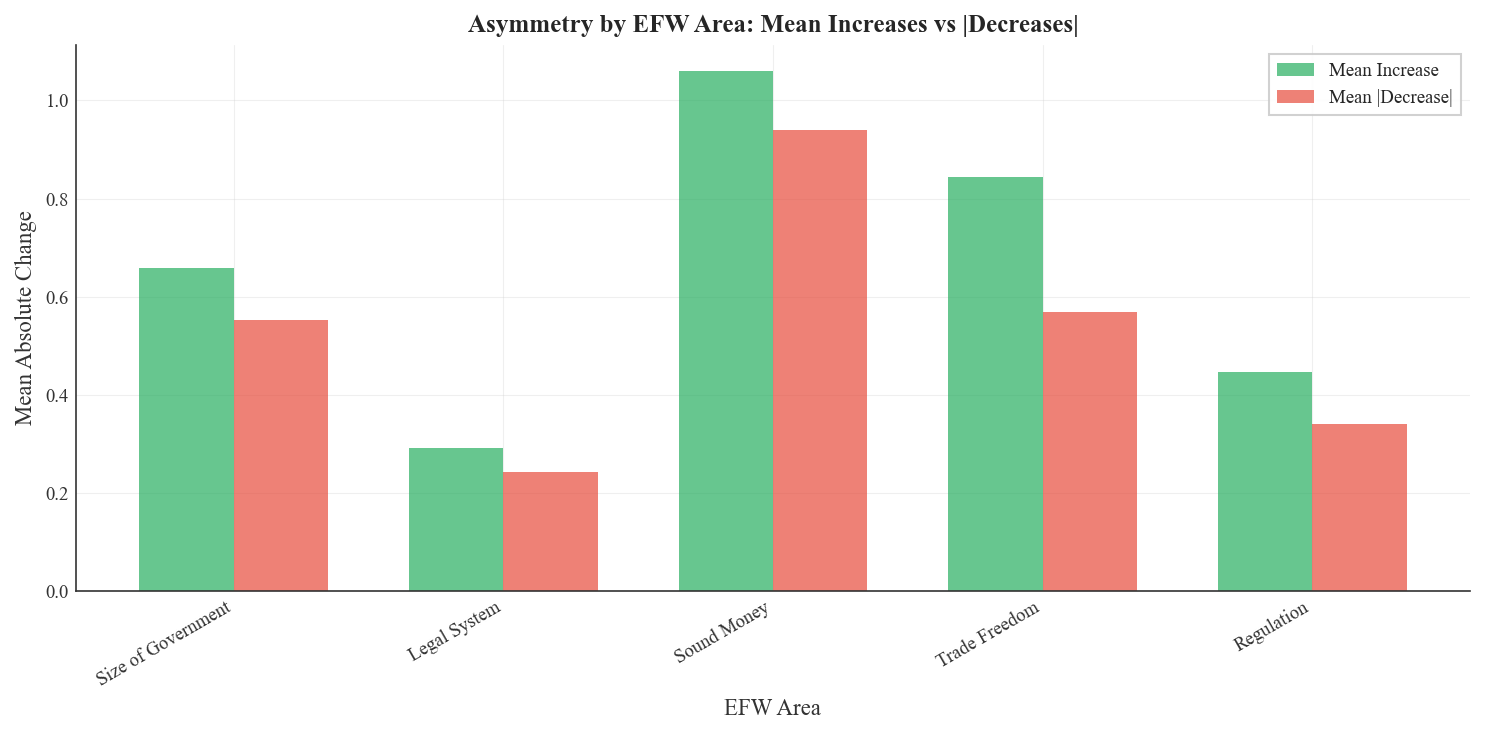

In [94]:
# -----------------------------------------------------------------------------
# III.2 EFW Area-Specific Asymmetry
# -----------------------------------------------------------------------------

# Analyze asymmetry by EFW component
area_asymmetry = []
for area in range(1, 6):
    col = f'efw_area{area}_delta_5y'
    if col in change_df.columns:
        s = change_df[col].dropna()
        if len(s) >= 20:
            pos = s[s > 0]
            neg = s[s < 0]
            area_asymmetry.append({
                'Area': f'Area {area}: {VAR_LABELS.get(f"efw_area{area}", f"Area {area}").split(": ")[-1]}',
                'N': len(s),
                'Mean Δ': s.mean(),
                'Share Positive': (s > 0).mean(),
                'Mean |Increase|': pos.mean() if len(pos) > 0 else np.nan,
                'Mean |Decrease|': neg.abs().mean() if len(neg) > 0 else np.nan,
                'Asymmetry Ratio': pos.mean() / neg.abs().mean() if len(pos) > 0 and len(neg) > 0 else np.nan,
            })

if area_asymmetry:
    area_asym_df = pd.DataFrame(area_asymmetry)
    show_table(area_asym_df, title="Table 15: Asymmetry by EFW Area")
    save_table(area_asym_df, 'table15_efw_area_asymmetry')
    
    # Figure 8: Area-specific asymmetry
    fig, ax = plt.subplots(figsize=(10, 5))
    
    x = range(len(area_asym_df))
    width = 0.35
    
    ax.bar([i - width/2 for i in x], area_asym_df['Mean |Increase|'], width, 
           label='Mean Increase', color=PALETTE['positive'], alpha=0.7)
    ax.bar([i + width/2 for i in x], area_asym_df['Mean |Decrease|'], width, 
           label='Mean |Decrease|', color=PALETTE['negative'], alpha=0.7)
    
    ax.set_xticks(x)
    ax.set_xticklabels([a.split(': ')[-1] for a in area_asym_df['Area']], rotation=30, ha='right')
    ax.set_ylabel('Mean Absolute Change')
    ax.set_xlabel('EFW Area')
    ax.set_title('Asymmetry by EFW Area: Mean Increases vs |Decreases|', fontweight='bold')
    ax.legend()
    ax.axhline(0, color='black', linewidth=0.5)
    
    plt.tight_layout()
    save_fig('fig8_area_asymmetry')
    plt.show()

---

## Section IV: Initial-State Dependence and Convergence

Do countries with low economic freedom catch up (convergence) or fall further behind (divergence)? This section examines the relationship between initial EFW levels and subsequent changes—a question central to understanding the dynamics of institutional development.

Observations with lagged EFW and change: 1,301


**Table 16: EFW Change by Initial Level Quintile**

,initial_quintile,n,initial_mean,change_mean,change_median,change_std,share_positive
0,Q1 (Low),261,4.159,0.320,0.324,0.668,0.697
1,Q2,260,5.341,0.174,0.192,0.547,0.650
2,Q3,260,6.075,0.098,0.080,0.480,0.558
3,Q4,260,6.865,0.060,0.069,0.382,0.577
4,Q5 (High),260,7.900,-0.022,-0.005,0.277,0.488



📊 β-Convergence Test:
   Δ EFW = 0.667 + (-0.0891) × EFW_lag5
   R² = 0.0555
   Interpretation: Convergence (p = 0.000, N = 1301)


**Table 30: β-Convergence Robustness**

,Specification,Beta (slope),SE,p-value,N,N (years)
0,Pooled,-0.089,0.010,0.000,1301.000,—
1,Year-demeaned (FE),-0.091,0.010,0.000,1301.000,—
2,Fama-MacBeth,-0.083,0.025,0.008,—,10.000


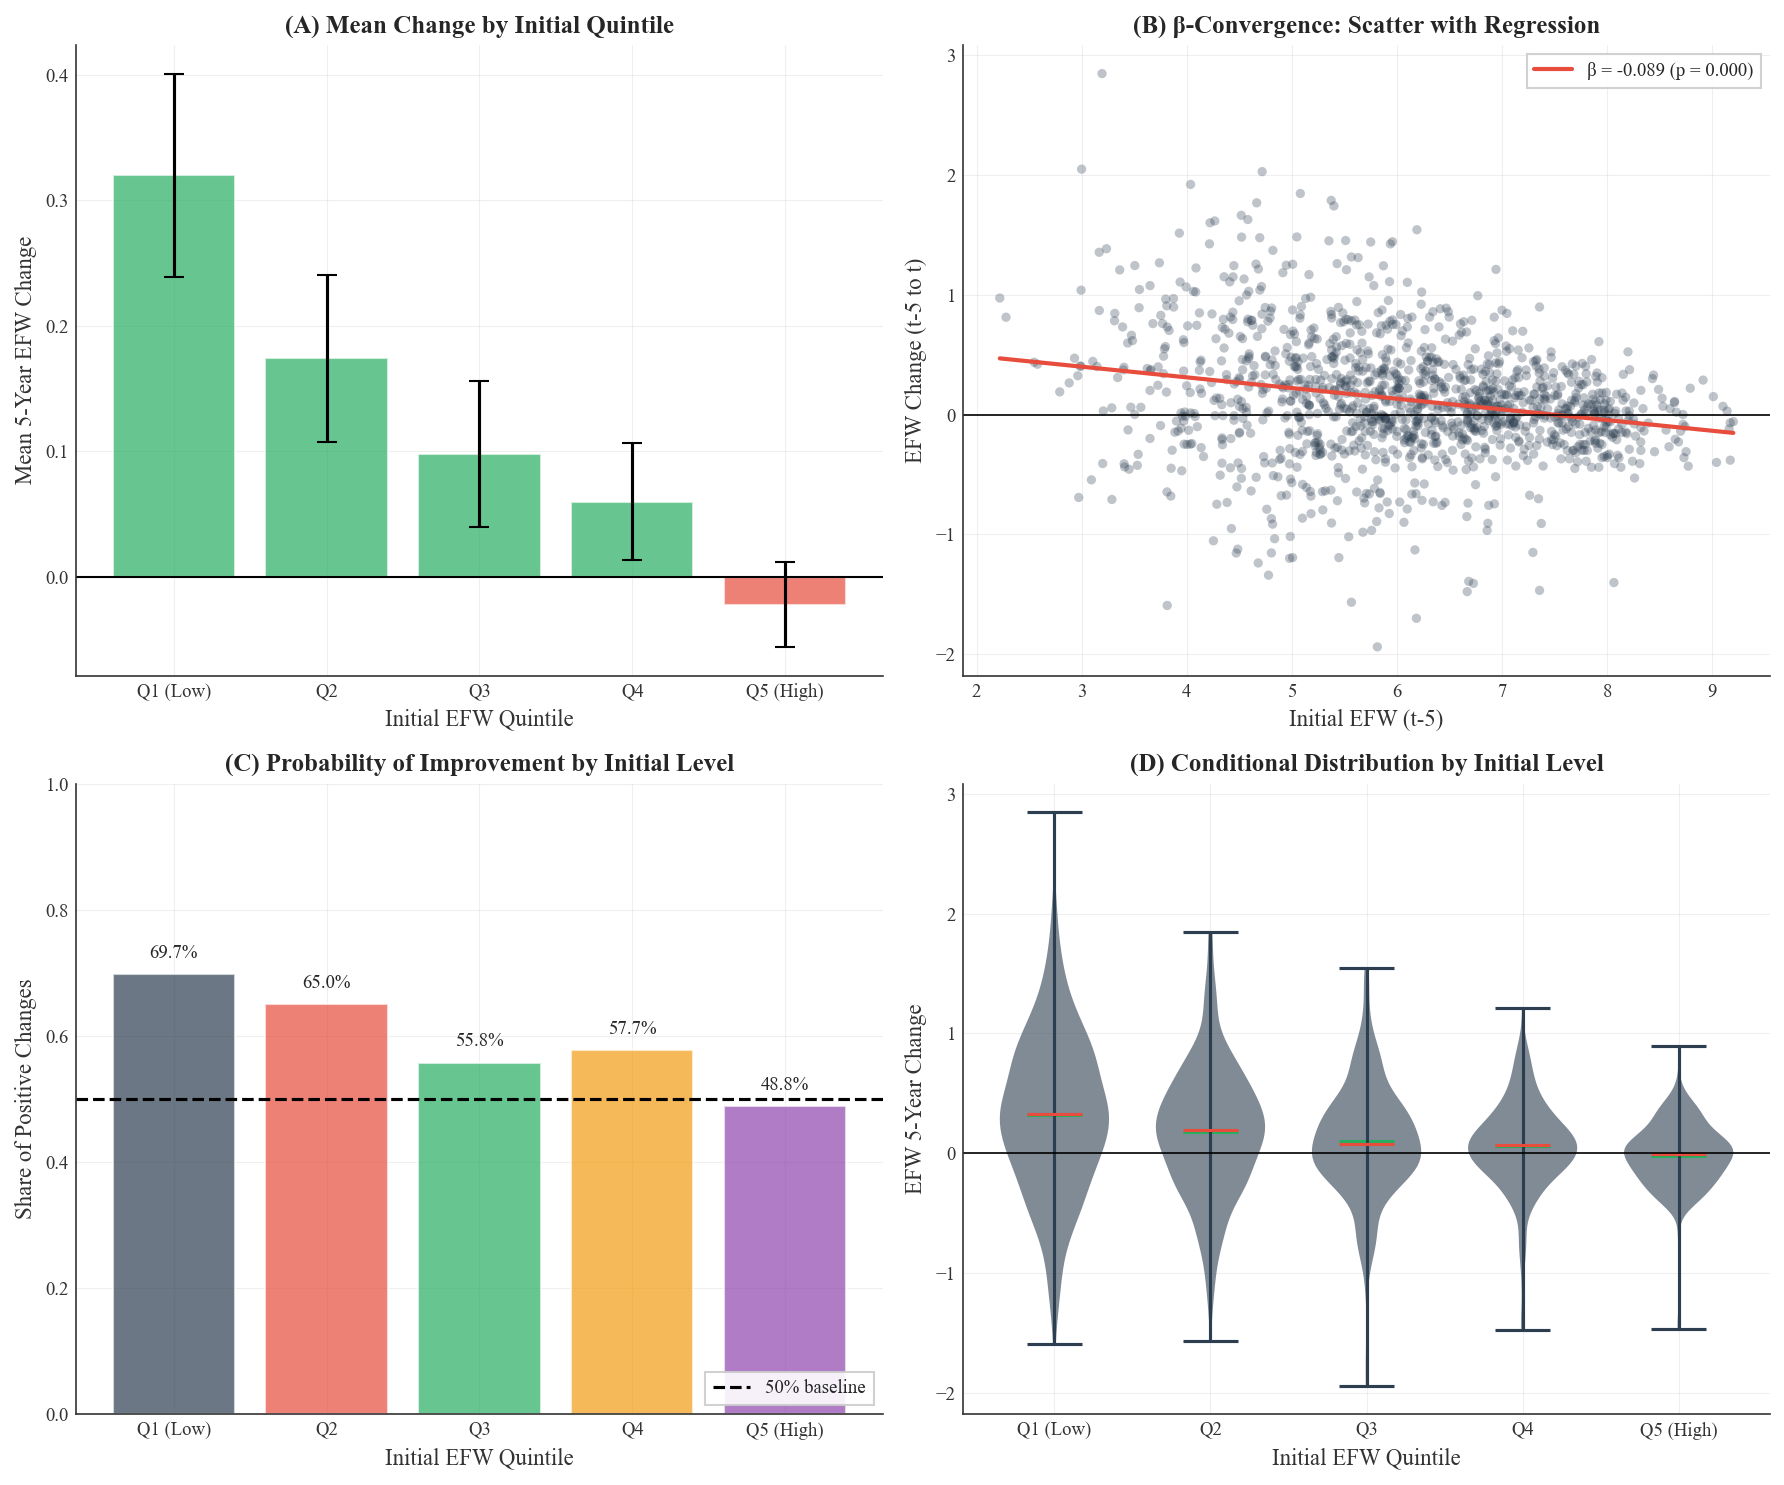

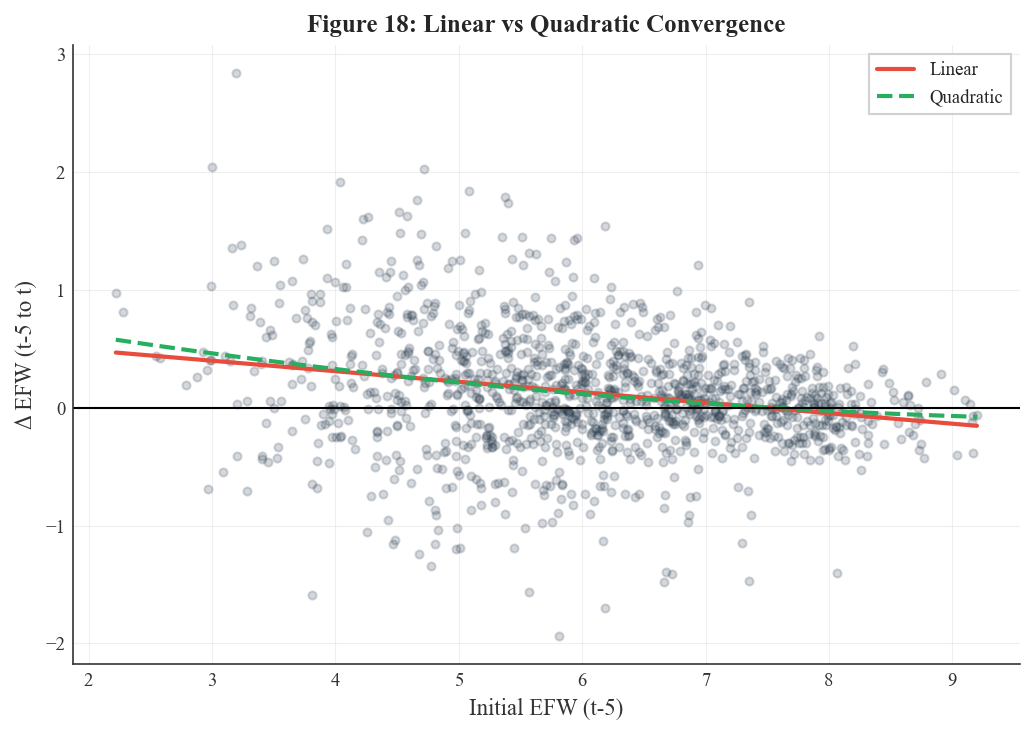

In [95]:
# =============================================================================
# SECTION IV: INITIAL-STATE DEPENDENCE AND CONVERGENCE
# =============================================================================

# -----------------------------------------------------------------------------
# IV.1 Mean Reversion Analysis
# -----------------------------------------------------------------------------

# Filter to valid observations
state_df = panel.dropna(subset=['efw_total_lag5', 'efw_delta_5y']).copy()
print(f"Observations with lagged EFW and change: {len(state_df):,}")

# Binned analysis: quintiles of initial EFW
state_df['initial_quintile'] = qcut_ranked(state_df['efw_total_lag5'], q=5, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)'])

# Summary by quintile
quintile_stats = state_df.groupby('initial_quintile').agg(
    n=('efw_delta_5y', 'count'),
    initial_mean=('efw_total_lag5', 'mean'),
    change_mean=('efw_delta_5y', 'mean'),
    change_median=('efw_delta_5y', 'median'),
    change_std=('efw_delta_5y', 'std'),
    share_positive=('efw_delta_5y', lambda s: (s > 0).mean()),
).reset_index()

show_table(quintile_stats, title="Table 16: EFW Change by Initial Level Quintile")
save_table(quintile_stats, 'table16_efw_change_by_initial_quintile')

# Regression: β-convergence (pooled)
slope, intercept, r_value, p_value, std_err, n_pool = safe_linregress(
    state_df['efw_total_lag5'], state_df['efw_delta_5y']
)
r2 = r_value**2 if np.isfinite(r_value) else np.nan

# Year-demeaned (FE-style)
state_df['efw_lag5_demean'] = state_df['efw_total_lag5'] - state_df.groupby('year')['efw_total_lag5'].transform('mean')
state_df['efw_delta_demean'] = state_df['efw_delta_5y'] - state_df.groupby('year')['efw_delta_5y'].transform('mean')

slope_fe, intercept_fe, r_fe, p_fe, se_fe, n_fe = safe_linregress(
    state_df['efw_lag5_demean'], state_df['efw_delta_demean']
)

# Fama-MacBeth (cross-section by year)
fm_slopes = []
for yr, g in state_df.groupby('year'):
    s, i, r, p, se, n = safe_linregress(g['efw_total_lag5'], g['efw_delta_5y'], min_n=10)
    if np.isfinite(s):
        fm_slopes.append(s)

fm_mean = np.mean(fm_slopes) if fm_slopes else np.nan
fm_se = np.std(fm_slopes, ddof=1) / np.sqrt(len(fm_slopes)) if len(fm_slopes) > 1 else np.nan
fm_t = fm_mean / fm_se if fm_se and np.isfinite(fm_se) else np.nan
fm_p = 2 * (1 - stats.t.cdf(abs(fm_t), df=len(fm_slopes)-1)) if len(fm_slopes) > 1 else np.nan

# Quadratic fit (non-linearity)
quad_sub = state_df[['efw_total_lag5', 'efw_delta_5y']].dropna()
quad_x = quad_sub['efw_total_lag5'].values
quad_y = quad_sub['efw_delta_5y'].values
quad_beta = np.linalg.lstsq(
    np.column_stack([np.ones(len(quad_x)), quad_x, quad_x**2]), quad_y, rcond=None
)[0]

print("\n📊 β-Convergence Test:")
print(f"   Δ EFW = {intercept:.3f} + ({slope:.4f}) × EFW_lag5")
print(f"   R² = {r2:.4f}")
print(f"   Interpretation: {'Convergence' if slope < 0 else 'Divergence'} " +
      f"(p = {p_value:.3f}, N = {n_pool})")

# Table 30: Convergence summary
convergence_summary = pd.DataFrame([
    {
        'Specification': 'Pooled',
        'Beta (slope)': slope,
        'SE': std_err,
        'p-value': p_value,
        'N': n_pool,
    },
    {
        'Specification': 'Year-demeaned (FE)',
        'Beta (slope)': slope_fe,
        'SE': se_fe,
        'p-value': p_fe,
        'N': n_fe,
    },
    {
        'Specification': 'Fama-MacBeth',
        'Beta (slope)': fm_mean,
        'SE': fm_se,
        'p-value': fm_p,
        'N (years)': len(fm_slopes),
    },
])
show_table(convergence_summary, title='Table 30: β-Convergence Robustness')
save_table(convergence_summary, 'table30_beta_convergence_robust')
# Figure 9: Initial State Dependence
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Panel A: Binned scatter (mean change by initial quintile)
ax1 = axes[0, 0]
x_pos = range(len(quintile_stats))
bars = ax1.bar(x_pos, quintile_stats['change_mean'], 
               color=[PALETTE['positive'] if v > 0 else PALETTE['negative'] for v in quintile_stats['change_mean']],
               alpha=0.7, edgecolor='white')

# Add error bars
se = quintile_stats['change_std'] / np.sqrt(quintile_stats['n'])
ax1.errorbar(x_pos, quintile_stats['change_mean'], yerr=1.96*se, 
             fmt='none', color='black', capsize=5, linewidth=1.5)

ax1.axhline(0, color='black', linewidth=1, linestyle='-')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(quintile_stats['initial_quintile'])
ax1.set_xlabel('Initial EFW Quintile')
ax1.set_ylabel('Mean 5-Year EFW Change')
ax1.set_title('(A) Mean Change by Initial Quintile', fontweight='bold')

# Panel B: Scatter with regression line
ax2 = axes[0, 1]
ax2.scatter(state_df['efw_total_lag5'], state_df['efw_delta_5y'], 
            alpha=0.3, s=20, color=PALETTE['primary'], edgecolor='none')

# Regression line
x_line = np.linspace(state_df['efw_total_lag5'].min(), state_df['efw_total_lag5'].max(), 100)
y_line = intercept + slope * x_line
ax2.plot(x_line, y_line, color=PALETTE['secondary'], linewidth=2, 
         label=f'β = {slope:.3f} (p = {p_value:.3f})')

ax2.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax2.set_xlabel('Initial EFW (t-5)')
ax2.set_ylabel('EFW Change (t-5 to t)')
ax2.set_title('(B) β-Convergence: Scatter with Regression', fontweight='bold')
ax2.legend(loc='upper right')

# Panel C: Share positive by initial quintile
ax3 = axes[1, 0]
bars3 = ax3.bar(x_pos, quintile_stats['share_positive'], 
                color=CATEGORY_COLORS[:len(x_pos)], alpha=0.7, edgecolor='white')
ax3.axhline(0.5, color='black', linewidth=1.5, linestyle='--', label='50% baseline')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(quintile_stats['initial_quintile'])
ax3.set_xlabel('Initial EFW Quintile')
ax3.set_ylabel('Share of Positive Changes')
ax3.set_title('(C) Probability of Improvement by Initial Level', fontweight='bold')
ax3.set_ylim(0, 1)
ax3.legend(loc='lower right')

for bar, val in zip(bars3, quintile_stats['share_positive']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{val:.1%}', ha='center', va='bottom', fontsize=9)

# Panel D: Conditional distribution (violin plot)
ax4 = axes[1, 1]
quintile_labels = ['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)']
quintile_data = [state_df[state_df['initial_quintile'] == q]['efw_delta_5y'].dropna() for q in quintile_labels]

parts = ax4.violinplot(quintile_data, positions=range(len(quintile_labels)), 
                        showmeans=True, showmedians=True, widths=0.7)
for pc in parts['bodies']:
    pc.set_facecolor(PALETTE['primary'])
    pc.set_alpha(0.6)
parts['cmeans'].set_color(PALETTE['tertiary'])
parts['cmedians'].set_color(PALETTE['secondary'])

ax4.axhline(0, color='black', linewidth=0.8)
ax4.set_xticks(range(len(quintile_labels)))
ax4.set_xticklabels(quintile_labels)
ax4.set_xlabel('Initial EFW Quintile')
ax4.set_ylabel('EFW 5-Year Change')
ax4.set_title('(D) Conditional Distribution by Initial Level', fontweight='bold')

plt.tight_layout()
save_fig('fig9_initial_state_dependence')
plt.show()

# Save convergence results
convergence_results = pd.DataFrame([{
    'Parameter': 'β (convergence coefficient)',
    'Estimate': slope,
    'Std. Error': std_err,
    't-statistic': slope / std_err,
    'p-value': p_value,
    'R-squared': r_value**2,
    'N': len(state_df),
    'Intercept': intercept,
}])
save_table(convergence_results, 'table17_beta_convergence')

# Figure 18: Convergence Non-linearity (Linear vs Quadratic)
fig18, ax18 = plt.subplots(1, 1, figsize=(7, 5))
ax18.scatter(state_df['efw_total_lag5'], state_df['efw_delta_5y'], alpha=0.2, s=15, color=PALETTE['primary'])

# Linear fit
if np.isfinite(slope):
    x_line = np.linspace(state_df['efw_total_lag5'].min(), state_df['efw_total_lag5'].max(), 200)
    ax18.plot(x_line, intercept + slope * x_line, color=PALETTE['secondary'], linewidth=2, label='Linear')

# Quadratic fit
if quad_beta is not None:
    x_line = np.linspace(state_df['efw_total_lag5'].min(), state_df['efw_total_lag5'].max(), 200)
    y_quad = quad_beta[0] + quad_beta[1] * x_line + quad_beta[2] * (x_line**2)
    ax18.plot(x_line, y_quad, color=PALETTE['tertiary'], linewidth=2, linestyle='--', label='Quadratic')

ax18.axhline(0, color='black', linewidth=1)
ax18.set_xlabel('Initial EFW (t-5)')
ax18.set_ylabel('Δ EFW (t-5 to t)')
ax18.set_title('Figure 18: Linear vs Quadratic Convergence', fontweight='bold')
ax18.legend()
plt.tight_layout()
save_fig('fig18_convergence_nonlinearity')
plt.show()




**Table 18: EFW Quintile Transition Probabilities (5-year)**

efw_quintile,Q1,Q2,Q3,Q4,Q5
efw_quintile_lag,,,,,
Q1,0.774,0.192,0.034,0.000,0.000
Q2,0.174,0.543,0.240,0.043,0.000
Q3,0.023,0.217,0.516,0.240,0.004
Q4,0.000,0.016,0.198,0.643,0.143
Q5,0.000,0.000,0.008,0.096,0.897



📊 Mobility Metrics (weighted by transitions):
   Persistence (staying in same quintile): 67.6%
   Upward mobility (moving to higher quintile): 17.9%
   Downward mobility (moving to lower quintile): 14.5%


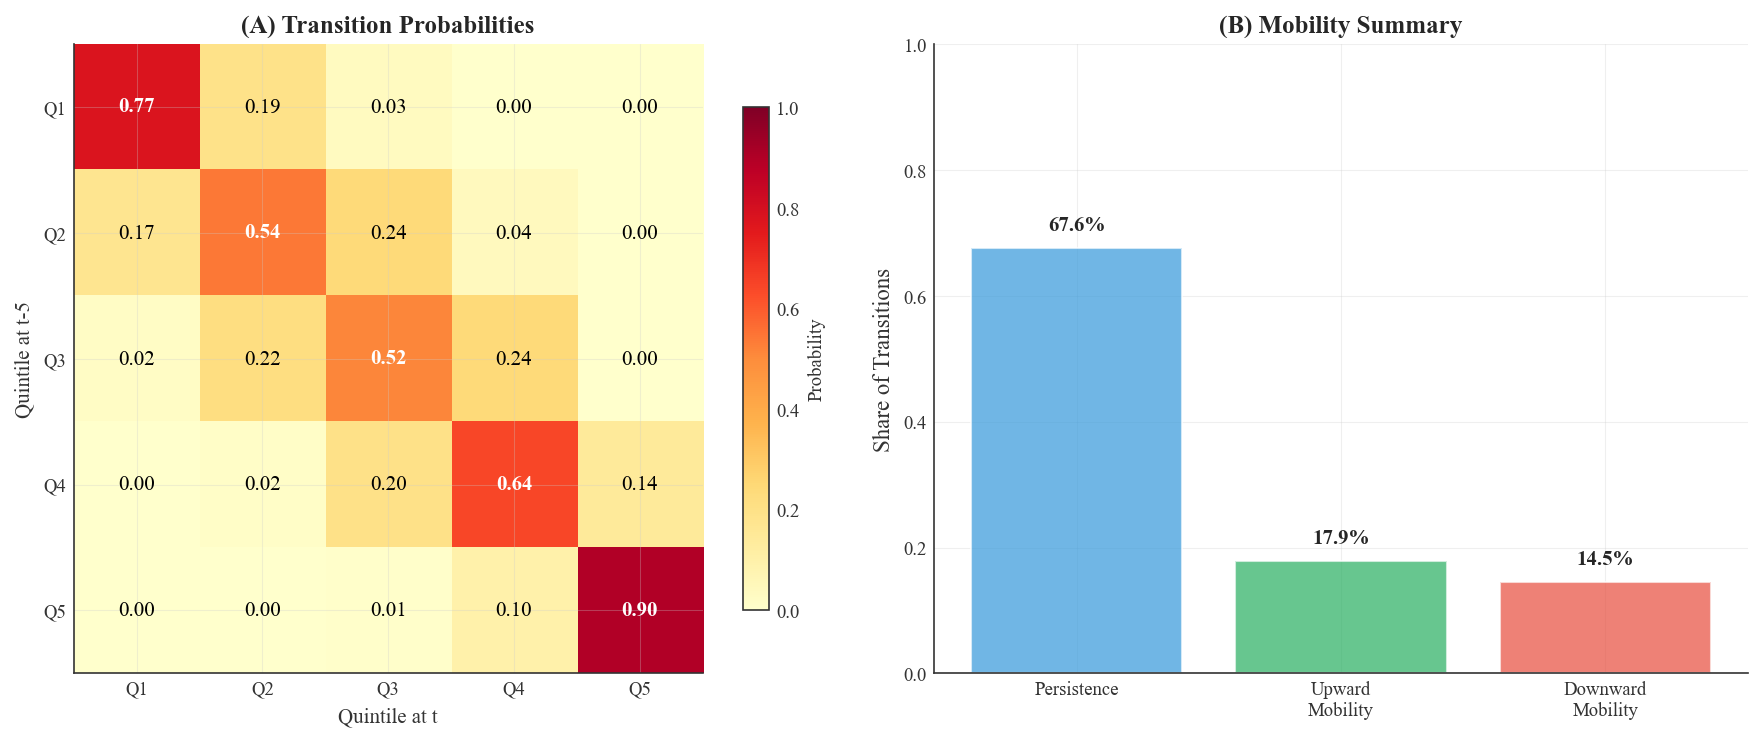


Figure 10: EFW quintile transitions
Note: High diagonal values indicate persistence; off-diagonal values show mobility.


In [96]:
# -----------------------------------------------------------------------------
# IV.2 Transition Probability Matrices
# -----------------------------------------------------------------------------

# Construct transition matrix of EFW quintiles
trans_df = panel.dropna(subset=['efw_total']).copy()

# Assign quintiles within each year (cross-sectional ranking)
trans_df['efw_quintile'] = trans_df.groupby('year')['efw_total'].transform(
    lambda s: qcut_ranked(s, q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
)

# Lagged quintile
trans_df = trans_df.sort_values(['iso3', 'year'])
trans_df['efw_quintile_lag'] = trans_df.groupby('iso3')['efw_quintile'].shift(1)

# Transition counts
trans_counts = (trans_df
    .dropna(subset=['efw_quintile_lag', 'efw_quintile'])
    .groupby(['efw_quintile_lag', 'efw_quintile'])
    .size()
    .unstack(fill_value=0)
)

# Transition probabilities (row-normalized)
trans_prob = trans_counts.div(trans_counts.sum(axis=1), axis=0)

# Display
show_table(trans_prob.round(3), title="Table 18: EFW Quintile Transition Probabilities (5-year)")
save_table(trans_prob.reset_index(), 'table18_efw_transition_probs')
save_table(trans_counts.reset_index(), 'table18b_efw_transition_counts')

# Mobility metrics
total_trans = trans_counts.values.sum()

# Weighted mobility metrics
persistence_rate = np.trace(trans_counts.values) / total_trans if total_trans > 0 else np.nan
upward_mobility = np.triu(trans_counts.values, 1).sum() / total_trans if total_trans > 0 else np.nan
downward_mobility = np.tril(trans_counts.values, -1).sum() / total_trans if total_trans > 0 else np.nan

print(f"\n📊 Mobility Metrics (weighted by transitions):")
print(f"   Persistence (staying in same quintile): {persistence_rate:.1%}")
print(f"   Upward mobility (moving to higher quintile): {upward_mobility:.1%}")
print(f"   Downward mobility (moving to lower quintile): {downward_mobility:.1%}")

# Figure 10: Transition Matrix Heatmap
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: Transition probability heatmap
ax1 = axes[0]
im1 = ax1.imshow(trans_prob.values, cmap='YlOrRd', vmin=0, vmax=1)

# Add text annotations
for i in range(len(trans_prob)):
    for j in range(len(trans_prob.columns)):
        val = trans_prob.values[i, j]
        text_color = 'white' if val > 0.4 else 'black'
        ax1.text(j, i, f'{val:.2f}', ha='center', va='center', 
                fontsize=10, fontweight='bold' if i == j else 'normal', color=text_color)

ax1.set_xticks(range(len(trans_prob.columns)))
ax1.set_xticklabels(trans_prob.columns)
ax1.set_yticks(range(len(trans_prob.index)))
ax1.set_yticklabels(trans_prob.index)
ax1.set_xlabel('Quintile at t', fontsize=10)
ax1.set_ylabel('Quintile at t-5', fontsize=10)
ax1.set_title('(A) Transition Probabilities', fontweight='bold')

cbar1 = plt.colorbar(im1, ax=ax1, shrink=0.8)
cbar1.set_label('Probability', fontsize=9)

# Panel B: Mobility visualization
ax2 = axes[1]

# Show persistence (diagonal) vs mobility
mobility_data = {
    'Persistence': persistence_rate,
    'Upward\nMobility': upward_mobility,
    'Downward\nMobility': downward_mobility,
}
colors = [PALETTE['neutral'], PALETTE['positive'], PALETTE['negative']]
bars = ax2.bar(mobility_data.keys(), mobility_data.values(), color=colors, alpha=0.7, edgecolor='white')

ax2.set_ylabel('Share of Transitions')
ax2.set_title('(B) Mobility Summary', fontweight='bold')
ax2.set_ylim(0, 1)

for bar, val in zip(bars, mobility_data.values()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{val:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
save_fig('fig10_transition_matrix')
plt.show()

print("\nFigure 10: EFW quintile transitions")
print("Note: High diagonal values indicate persistence; off-diagonal values show mobility.")


---

## Section V: Logarithmic and Percentage Change Analysis

A fundamental question in empirical economics is whether relationships are best described in **levels** (absolute changes) or **logs** (percentage changes). This section investigates whether the association between EFW and macroeconomic variables differs across functional forms.

### Why this matters:
- **Level changes** assume that a 1-point increase in EFW has the same effect regardless of starting point.
- **Log/percentage changes** assume that proportional changes matter more—e.g., going from 3→4 (33% increase) differs from 7→8 (14% increase).

We systematically compare correlations using both specifications.

Note: log(EFW) is an approximation on a bounded index; logit(EFW) is the preferred scale for proportional changes.
✓ Constructed log transformations for 12 variables


/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_57394/1510107307.py:57: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  panel[f'{v}_pct_5y'] = (panel[v] - lag_5) / lag_5 * 100
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_57394/1510107307.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  panel[f'log_{v}'] = safe_log(panel[v])
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_57394/1510107307.py:53: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.

**Table 19: Level vs Log Correlations with EFW Changes**

,Variable,Correlation (Level Δ EFW vs Log Δ Macro),Correlation (Log Δ EFW vs Log Δ Macro),N
4,macro_debt_gdp,-0.313,-0.319,190
8,PWT: TFP at constant prices,0.201,0.177,995
0,Log Real GDP per capita,0.181,0.151,1287
11,pwt_avh,0.171,0.152,737
6,PWT: Output-side GDP,0.158,0.153,1282
3,Private Credit (% of GDP),0.141,0.137,919
7,PWT: TFP at current PPPs,0.138,0.132,995
10,pwt_csh_i,0.133,0.110,1282
2,Government Consumption (% of GDP),-0.074,-0.072,1133
1,Trade (% of GDP),0.035,0.046,1143


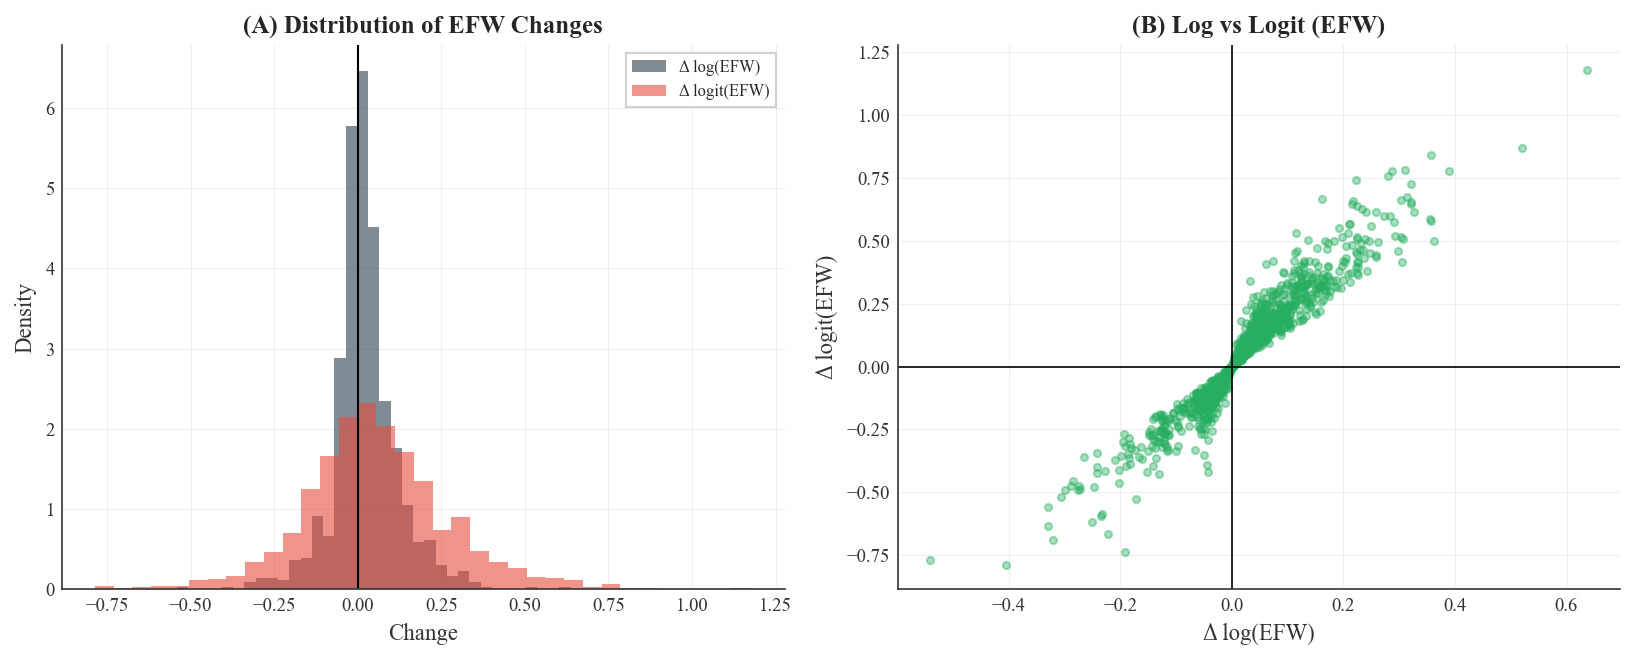

In [97]:
# =============================================================================
# SECTION V: LOGARITHMIC AND PERCENTAGE CHANGE ANALYSIS
# =============================================================================

# -----------------------------------------------------------------------------
# V.1 Construct Log Transformations
# -----------------------------------------------------------------------------

# Log of EFW (for percentage change interpretation)
# Note: EFW is on a 0-10 scale, so we can interpret log changes
panel['log_efw_total'] = safe_log(panel['efw_total'])
panel['log_efw_total_lag5_raw'] = panel.groupby('iso3')['log_efw_total'].shift(1)
panel['log_efw_total_lag5'] = panel['log_efw_total_lag5_raw'].where(panel['is_5y_gap'])
panel['log_efw_delta_5y'] = panel['log_efw_total'] - panel['log_efw_total_lag5']

# Logit transform of bounded EFW (0-10)
EFW_MIN, EFW_MAX = 0.0, 10.0
EFW_EPS = 1e-3
panel['efw_scaled'] = (panel['efw_total'] - EFW_MIN) / (EFW_MAX - EFW_MIN)
panel['efw_scaled_clip'] = panel['efw_scaled'].clip(EFW_EPS, 1 - EFW_EPS)
panel['efw_logit'] = np.log(panel['efw_scaled_clip'] / (1 - panel['efw_scaled_clip']))
panel['efw_logit_lag5'] = panel.groupby('iso3')['efw_logit'].shift(1)
panel.loc[~panel['is_5y_gap'], 'efw_logit_lag5'] = np.nan
panel['efw_logit_delta_5y'] = panel['efw_logit'] - panel['efw_logit_lag5']

print("Note: log(EFW) is an approximation on a bounded index; logit(EFW) is the preferred scale for proportional changes.")


# Approximate percentage change in EFW
panel['efw_pct_change_5y'] = (panel['efw_total'] - panel['efw_total_lag5']) / panel['efw_total_lag5'] * 100

# For macro variables: create log and percentage change versions
log_analysis_vars = []

for v in MACRO_VARS + PWT_VARS:
    if v in panel.columns:
        # Already logged variables (identified by '_log' in name)
        if '_log' in v:
            # These are already in logs; compute log-diff (≈ percentage change)
            lag_raw = panel.groupby('iso3')[v].shift(1)
            panel[f'{v}_lag5'] = lag_raw.where(panel['is_5y_gap'])
            panel[f'{v}_delta_5y'] = panel[v] - panel[f'{v}_lag5']
            log_analysis_vars.append({
                'original': v,
                'log_diff': f'{v}_delta_5y',
                'is_already_log': True
            })
        else:
            # Not logged: create log version and compute both diffs
            if panel[v].min() > 0 or (panel[v] > 0).mean() > 0.8:  # Mostly positive
                panel[f'log_{v}'] = safe_log(panel[v])
                lag_raw = panel.groupby('iso3')[f'log_{v}'].shift(1)
                panel[f'log_{v}_lag5'] = lag_raw.where(panel['is_5y_gap'])
                panel[f'log_{v}_delta_5y'] = panel[f'log_{v}'] - panel[f'log_{v}_lag5']
                lag_raw = panel.groupby('iso3')[v].shift(1)
                lag_5 = lag_raw.where(panel['is_5y_gap'])
                panel[f'{v}_pct_5y'] = (panel[v] - lag_5) / lag_5 * 100
                log_analysis_vars.append({
                    'original': v,
                    'log_diff': f'log_{v}_delta_5y',
                    'pct_change': f'{v}_pct_5y',
                    'is_already_log': False
                })

print(f"✓ Constructed log transformations for {len(log_analysis_vars)} variables")

# -----------------------------------------------------------------------------
# V.2 Compare Level vs Log Correlations
# -----------------------------------------------------------------------------

def compare_correlations(df: pd.DataFrame, y_level: str, y_log: str, x_level: str, x_log: str = None) -> dict:
    """
    Compare correlations using level differences vs log differences.
    Returns Pearson correlations and Fisher-z 95% confidence intervals.
    """
    result = {'y_var': y_level, 'x_var': x_level}
    
    # Level-level correlation
    if y_level in df.columns and x_level in df.columns:
        sub = df[[y_level, x_level]].dropna()
        if len(sub) >= 30:
            r, p, n = safe_pearsonr(sub[y_level], sub[x_level])
            result['corr_level_level'] = r
            result['p_level_level'] = p
            lo, hi = corr_ci(r, n)
            result['ci_level_low'] = lo
            result['ci_level_high'] = hi
            result['n_level'] = len(sub)
    
    # Log-log correlation (for percentage interpretation)
    if y_log and x_log and y_log in df.columns and x_log in df.columns:
        sub = df[[y_log, x_log]].dropna()
        if len(sub) >= 30:
            r, p, n = safe_pearsonr(sub[y_log], sub[x_log])
            result['corr_log_log'] = r
            result['p_log_log'] = p
            result['n_log'] = n
            lo, hi = corr_ci(r, n)
            result['ci_log_low'] = lo
            result['ci_log_high'] = hi
    
    return result


# EFW level change vs macro log changes
comparison_results = []

for var_info in log_analysis_vars:
    orig = var_info['original']
    log_diff = var_info.get('log_diff')
    
    # EFW level Δ vs macro log Δ
    if log_diff and log_diff in panel.columns and 'efw_delta_5y' in panel.columns:
        sub = panel[['efw_delta_5y', log_diff]].dropna()
        if len(sub) >= 30:
            r_level_vs_log, p, n_lv = safe_pearsonr(sub['efw_delta_5y'], sub[log_diff])
            
            # Also compute EFW log Δ vs macro log Δ
            if 'log_efw_delta_5y' in panel.columns:
                sub2 = panel[['log_efw_delta_5y', log_diff]].dropna()
                if len(sub2) >= 30:
                    r_log_vs_log, p2, n_ll = safe_pearsonr(sub2['log_efw_delta_5y'], sub2[log_diff])
                else:
                    r_log_vs_log = np.nan
            else:
                r_log_vs_log = np.nan
            
            comparison_results.append({
                'Variable': VAR_LABELS.get(orig, orig),
                'Correlation (Level Δ EFW vs Log Δ Macro)': r_level_vs_log,
                'Correlation (Log Δ EFW vs Log Δ Macro)': r_log_vs_log,
                'N': len(sub),
            })

if comparison_results:
    comparison_df = pd.DataFrame(comparison_results)
    comparison_df = comparison_df.sort_values('Correlation (Level Δ EFW vs Log Δ Macro)', key=lambda s: s.abs(), ascending=False)
    show_table(comparison_df, title="Table 19: Level vs Log Correlations with EFW Changes")
    save_table(comparison_df, 'table19_level_vs_log_correlations')

# Figure 17: Log vs Logit Change in EFW
fig17, axes17 = plt.subplots(1, 2, figsize=(11, 4.5))

# Panel A: Distributions
ax17a = axes17[0]
log_delta = panel['log_efw_delta_5y'].dropna()
logit_delta = panel['efw_logit_delta_5y'].dropna()
ax17a.hist(log_delta, bins=35, alpha=0.6, color=PALETTE['primary'], density=True, label='Δ log(EFW)')
ax17a.hist(logit_delta, bins=35, alpha=0.6, color=PALETTE['secondary'], density=True, label='Δ logit(EFW)')
ax17a.axvline(0, color='black', linewidth=1)
ax17a.set_title('(A) Distribution of EFW Changes')
ax17a.set_xlabel('Change')
ax17a.set_ylabel('Density')
ax17a.legend(fontsize=8)

# Panel B: Scatter comparison
ax17b = axes17[1]
scatter = panel[['log_efw_delta_5y', 'efw_logit_delta_5y']].dropna()
ax17b.scatter(scatter['log_efw_delta_5y'], scatter['efw_logit_delta_5y'], alpha=0.4, s=12, color=PALETTE['tertiary'])
ax17b.axhline(0, color='black', linewidth=0.8)
ax17b.axvline(0, color='black', linewidth=0.8)
ax17b.set_xlabel('Δ log(EFW)')
ax17b.set_ylabel('Δ logit(EFW)')
ax17b.set_title('(B) Log vs Logit (EFW)')

plt.tight_layout()
save_fig('fig17_log_vs_logit')
plt.show()



/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_57394/651084221.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  panel[log_v] = safe_log(panel[v])
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_57394/651084221.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  panel[log_v_delta] = panel.groupby('iso3')[log_v].diff()


**Table 20: Log-Log Elasticities (EFW vs Macro Variables)**

,Variable,Specification,Elasticity,SE,R²,p-value,N
0,Log Real GDP per capita,Levels (cross-sectional),0.100,0.003,0.415,0.000,1451
1,Log Real GDP per capita,Changes (within-country),0.093,0.017,0.023,0.000,1287
2,Trade (% of GDP),Levels (cross-sectional),0.141,0.010,0.133,0.000,1300
3,Trade (% of GDP),Changes (within-country),0.020,0.013,0.002,0.118,1143
4,Investment (% of GDP),Levels (cross-sectional),0.153,0.017,0.061,0.000,1250
5,Investment (% of GDP),Changes (within-country),0.036,0.009,0.015,0.000,1092
6,Private Credit (% of GDP),Levels (cross-sectional),0.138,0.005,0.431,0.000,1086
7,Private Credit (% of GDP),Changes (within-country),0.034,0.008,0.019,0.000,919


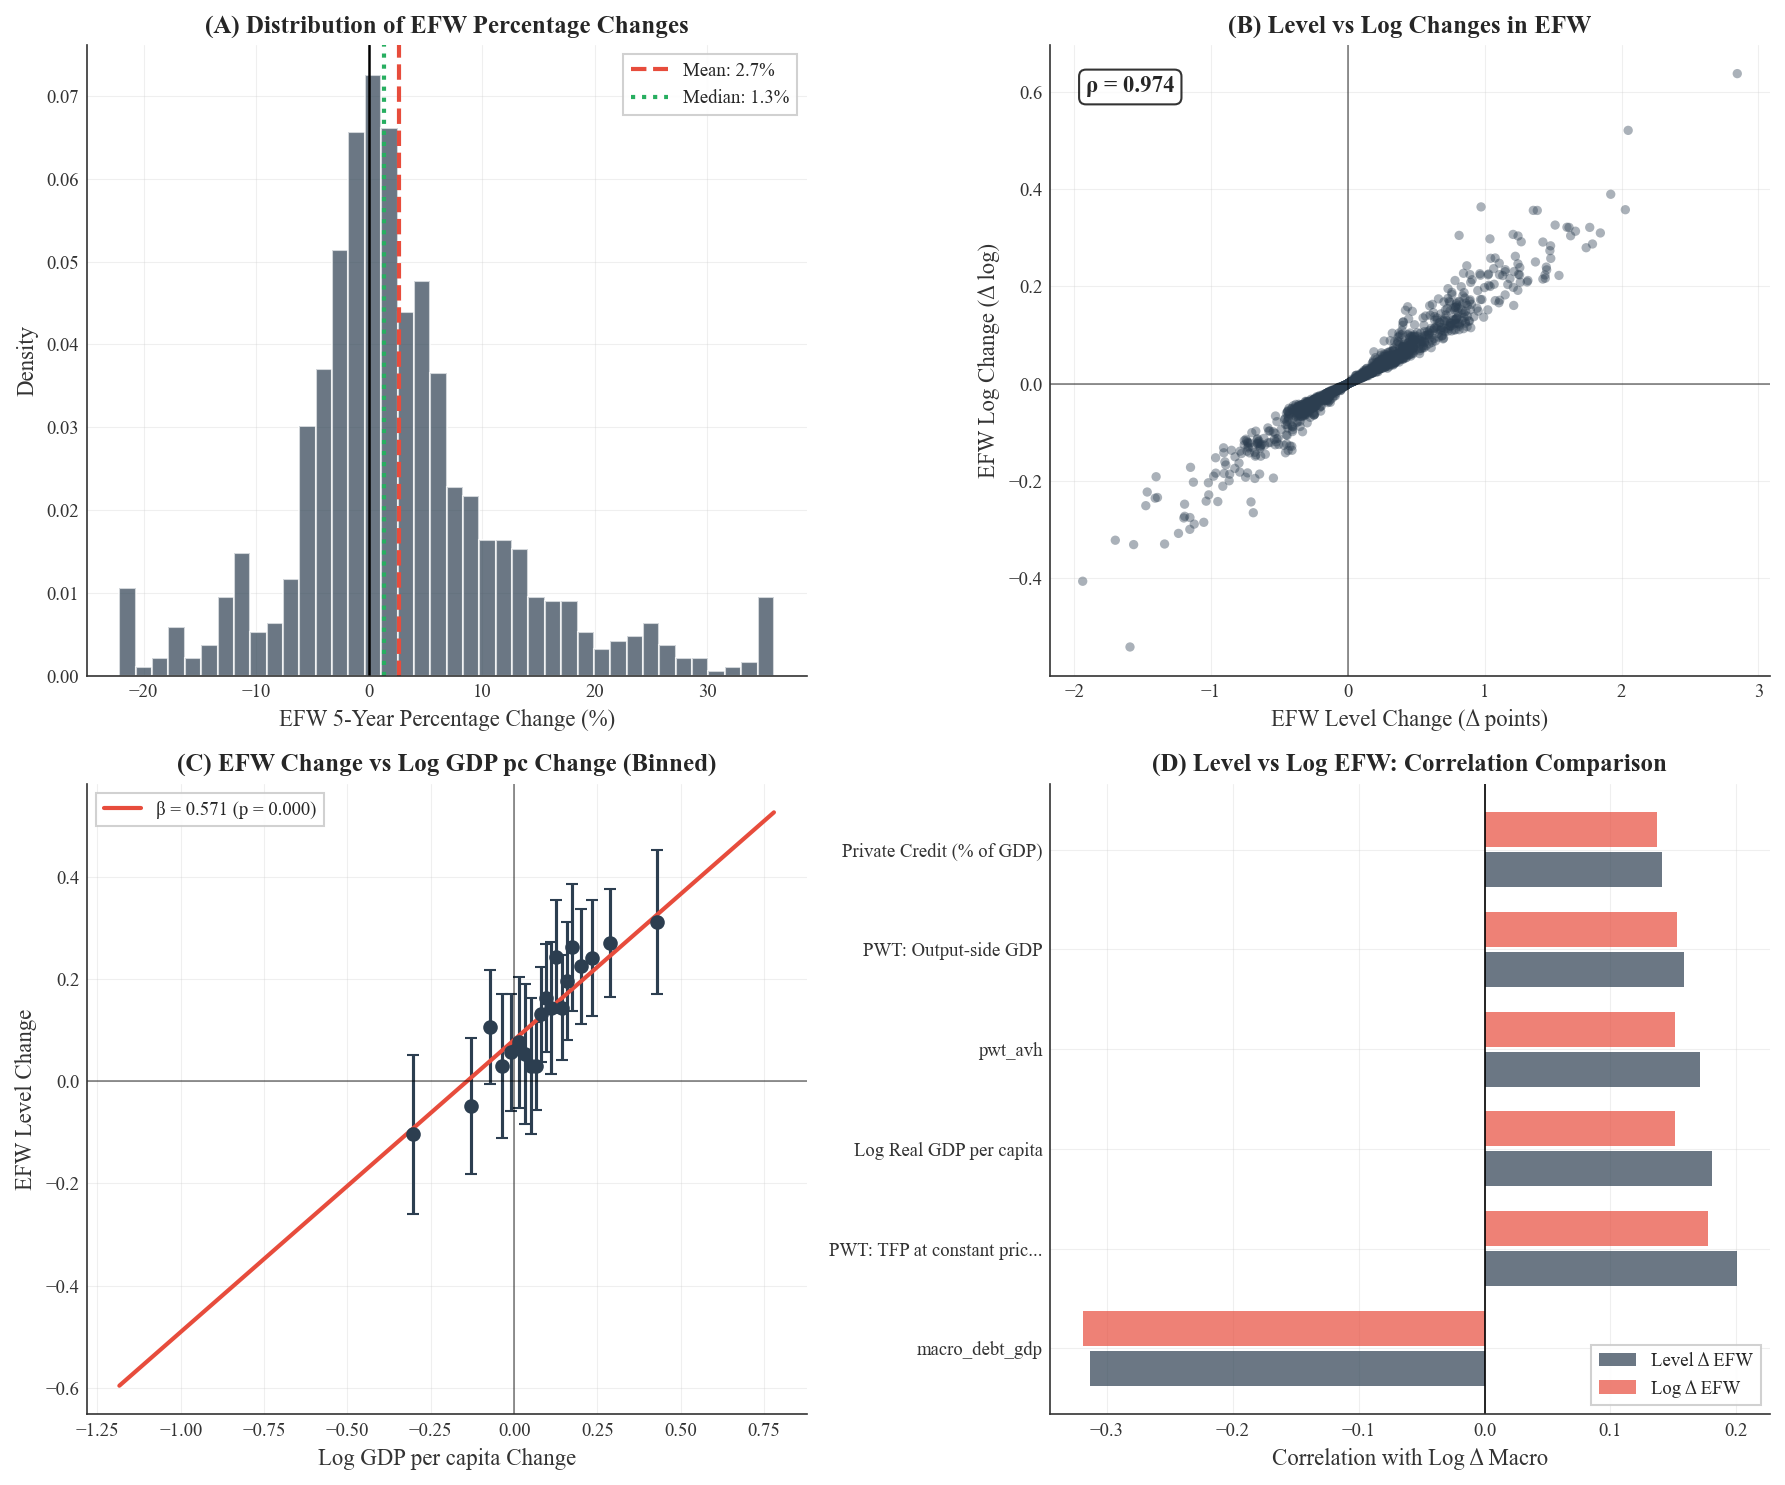


Figure 11: Logarithmic and percentage change analysis
Key insight: Log specifications capture proportional effects, which may be
             more meaningful when comparing countries at different development levels.


In [98]:
# -----------------------------------------------------------------------------
# V.3 Elasticity Analysis: Log-Log Regressions
# -----------------------------------------------------------------------------

# For positive macro variables, estimate "elasticities" using log-log specification
# Interpretation: 1% change in macro variable ↔ X% change in EFW

elasticity_results = []

for v in ['macro_gdp_pc_real_log', 'macro_trade_gdp', 'macro_inv_gdp', 'macro_credit_private_gdp']:
    if v not in panel.columns:
        continue
    
    # Construct log version if needed
    if '_log' not in v:
        log_v = f'log_{v}'
        if log_v not in panel.columns:
            panel[log_v] = safe_log(panel[v])
    else:
        log_v = v
    
    # Log EFW vs Log macro (levels)
    sub = panel[['log_efw_total', log_v]].dropna()
    if len(sub) >= 30:
        slope, intercept, r, p, se = linregress(sub[log_v], sub['log_efw_total'])
        elasticity_results.append({
            'Variable': VAR_LABELS.get(v, v),
            'Specification': 'Levels (cross-sectional)',
            'Elasticity': slope,
            'SE': se,
            'R²': r**2,
            'p-value': p,
            'N': len(sub),
        })
    
    # Log changes (within-country)
    log_v_delta = f'{log_v}_delta_5y' if '_log' not in v else f'{v}_delta_5y'
    if log_v_delta not in panel.columns:
        panel[log_v_delta] = panel.groupby('iso3')[log_v].diff()
    
    sub_chg = panel[['log_efw_delta_5y', log_v_delta]].dropna()
    if len(sub_chg) >= 30:
        slope_chg, intercept_chg, r_chg, p_chg, se_chg = linregress(sub_chg[log_v_delta], sub_chg['log_efw_delta_5y'])
        elasticity_results.append({
            'Variable': VAR_LABELS.get(v, v),
            'Specification': 'Changes (within-country)',
            'Elasticity': slope_chg,
            'SE': se_chg,
            'R²': r_chg**2,
            'p-value': p_chg,
            'N': len(sub_chg),
        })

if elasticity_results:
    elasticity_df = pd.DataFrame(elasticity_results)
    show_table(elasticity_df, title="Table 20: Log-Log Elasticities (EFW vs Macro Variables)")
    save_table(elasticity_df, 'table20_log_elasticities')

# Figure 11: Level vs Log Comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Panel A: EFW percentage change distribution
ax1 = axes[0, 0]
pct_change = panel['efw_pct_change_5y'].dropna()
pct_change_winsorized = winsorize(pct_change, 0.01, 0.99)

ax1.hist(pct_change_winsorized, bins=40, color=PALETTE['primary'], alpha=0.7, edgecolor='white', density=True)
ax1.axvline(0, color='black', linewidth=1.2)
ax1.axvline(pct_change_winsorized.mean(), color=PALETTE['secondary'], linewidth=2, linestyle='--',
            label=f'Mean: {pct_change_winsorized.mean():.1f}%')
ax1.axvline(pct_change_winsorized.median(), color=PALETTE['tertiary'], linewidth=2, linestyle=':',
            label=f'Median: {pct_change_winsorized.median():.1f}%')
ax1.set_xlabel('EFW 5-Year Percentage Change (%)')
ax1.set_ylabel('Density')
ax1.set_title('(A) Distribution of EFW Percentage Changes', fontweight='bold')
ax1.legend(loc='upper right')

# Panel B: Scatter - Level change vs Log change
ax2 = axes[0, 1]
scatter_data = panel[['efw_delta_5y', 'log_efw_delta_5y']].dropna()
ax2.scatter(scatter_data['efw_delta_5y'], scatter_data['log_efw_delta_5y'], 
            alpha=0.4, s=20, color=PALETTE['primary'], edgecolor='none')
ax2.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax2.axvline(0, color='black', linewidth=0.8, alpha=0.5)

# Add correlation annotation
corr_lvl_log = scatter_data.corr().iloc[0, 1]
ax2.annotate(f'ρ = {corr_lvl_log:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
             fontsize=11, fontweight='bold', ha='left', va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax2.set_xlabel('EFW Level Change (Δ points)')
ax2.set_ylabel('EFW Log Change (Δ log)')
ax2.set_title('(B) Level vs Log Changes in EFW', fontweight='bold')

# Panel C: Binned scatter - EFW change vs log GDP pc change
ax3 = axes[1, 0]
gdp_log_delta = 'macro_gdp_pc_real_log_delta_5y'
if gdp_log_delta in panel.columns:
    tmp = panel[['efw_delta_5y', gdp_log_delta]].dropna()
    if len(tmp) >= 30:
        tmp['bin'] = pd.qcut(tmp[gdp_log_delta], q=20, duplicates='drop')
        binned = tmp.groupby('bin').agg(
            x_mean=(gdp_log_delta, 'mean'),
            y_mean=('efw_delta_5y', 'mean'),
            y_se=('efw_delta_5y', lambda s: s.std() / np.sqrt(len(s)))
        ).reset_index()
        
        ax3.errorbar(binned['x_mean'], binned['y_mean'], yerr=1.96*binned['y_se'],
                     fmt='o', color=PALETTE['primary'], markersize=6, capsize=3, linewidth=1.5)
        
        # Add regression line
        slope, intercept, r, p, se = linregress(tmp[gdp_log_delta], tmp['efw_delta_5y'])
        x_line = np.linspace(tmp[gdp_log_delta].min(), tmp[gdp_log_delta].max(), 100)
        ax3.plot(x_line, intercept + slope * x_line, color=PALETTE['secondary'], linewidth=2,
                 label=f'β = {slope:.3f} (p = {p:.3f})')
        
        ax3.axhline(0, color='black', linewidth=0.8, alpha=0.5)
        ax3.axvline(0, color='black', linewidth=0.8, alpha=0.5)
        ax3.set_xlabel('Log GDP per capita Change')
        ax3.set_ylabel('EFW Level Change')
        ax3.set_title('(C) EFW Change vs Log GDP pc Change (Binned)', fontweight='bold')
        ax3.legend(loc='upper left')

# Panel D: Comparison of correlation magnitudes
ax4 = axes[1, 1]
if comparison_results:
    # Show top 6 by absolute correlation
    top_vars = comparison_df.head(6)
    y_pos = range(len(top_vars))
    
    ax4.barh([y - 0.2 for y in y_pos], top_vars['Correlation (Level Δ EFW vs Log Δ Macro)'], 
             height=0.35, color=PALETTE['primary'], alpha=0.7, label='Level Δ EFW')
    ax4.barh([y + 0.2 for y in y_pos], top_vars['Correlation (Log Δ EFW vs Log Δ Macro)'], 
             height=0.35, color=PALETTE['secondary'], alpha=0.7, label='Log Δ EFW')
    
    ax4.axvline(0, color='black', linewidth=0.8)
    ax4.set_yticks(y_pos)
    ax4.set_yticklabels([v[:25] + '...' if len(v) > 25 else v for v in top_vars['Variable']])
    ax4.set_xlabel('Correlation with Log Δ Macro')
    ax4.set_title('(D) Level vs Log EFW: Correlation Comparison', fontweight='bold')
    ax4.legend(loc='lower right')

plt.tight_layout()
save_fig('fig11_log_analysis')
plt.show()

print("\nFigure 11: Logarithmic and percentage change analysis")
print("Key insight: Log specifications capture proportional effects, which may be")
print("             more meaningful when comparing countries at different development levels.")

---

## Section VI: Within- vs Between-Country Variation

Understanding the structure of variation in panel data is fundamental for causal inference. This section decomposes EFW variation into:

1. **Between-country variation**: Differences across countries (cross-sectional)
2. **Within-country variation**: Changes over time for the same country (time-series)

This decomposition informs the choice of estimation strategy and the interpretation of correlations.

In [99]:
# =============================================================================
# SECTION VI: WITHIN- VS BETWEEN-COUNTRY VARIATION
# =============================================================================

# -----------------------------------------------------------------------------
# VI.1 Variance Decomposition
# -----------------------------------------------------------------------------

def variance_decomposition(df: pd.DataFrame, var: str, group: str = 'iso3') -> dict:
    """ANOVA-style variance decomposition (between vs within)."""
    sub = df[[group, var]].dropna()
    n = len(sub)
    if n < 2:
        return {}

    overall_mean = sub[var].mean()
    stats_g = sub.groupby(group)[var].agg(['mean', 'var', 'count'])

    between_ss = ((stats_g['mean'] - overall_mean) ** 2 * stats_g['count']).sum()
    within_ss = ((stats_g['count'] - 1) * stats_g['var']).sum()

    total_var = (between_ss + within_ss) / (n - 1)
    between_var = between_ss / (n - 1)
    within_var = within_ss / (n - 1)

    between_share = 100 * between_var / total_var if total_var > 0 else np.nan
    within_share = 100 * within_var / total_var if total_var > 0 else np.nan

    return {
        'Variable': VAR_LABELS.get(var, var),
        'N': n,
        'Total Variance': total_var,
        'Between Variance': between_var,
        'Within Variance': within_var,
        'Between Share (%)': between_share,
        'Within Share (%)': within_share,
    }


# Decompose EFW and key macro variables
decomp_vars = ['efw_total'] + [v for v in MACRO_VARS + PWT_VARS if v in panel.columns][:8]

decomp_results = []
for v in decomp_vars:
    result = variance_decomposition(panel, v)
    if result:
        decomp_results.append(result)

if decomp_results:
    decomp_df = pd.DataFrame(decomp_results)
    decomp_df = decomp_df.sort_values('Between Share (%)', ascending=False)
    show_table(decomp_df, title="Table 21: Variance Decomposition (Between vs Within Country)")
    save_table(decomp_df, 'table21_variance_decomposition')

# -----------------------------------------------------------------------------
# VI.2 Within- vs Between-Country Correlations
# -----------------------------------------------------------------------------

def within_between_correlation(df: pd.DataFrame, x: str, y: str, group: str = 'iso3') -> dict:
    """
    Compute within and between-group correlations separately.
    """
    sub = df[[group, x, y]].dropna()
    if len(sub) < 30 or sub[group].nunique() < 10:
        return {}
    
    # Between correlation (correlation of group means)
    means = sub.groupby(group)[[x, y]].mean()
    if len(means) >= 5:
        corr_between, p_between, _ = safe_pearsonr(means[x], means[y], min_n=10)
    else:
        corr_between, p_between = np.nan, np.nan
    
    # Within correlation (demeaned variables)
    sub[f'{x}_demean'] = sub[x] - sub.groupby(group)[x].transform('mean')
    sub[f'{y}_demean'] = sub[y] - sub.groupby(group)[y].transform('mean')
    
    demean_sub = sub[[f'{x}_demean', f'{y}_demean']].dropna()
    if len(demean_sub) >= 10:
        corr_within, p_within, _ = safe_pearsonr(demean_sub[f'{x}_demean'], demean_sub[f'{y}_demean'], min_n=10)
    else:
        corr_within, p_within = np.nan, np.nan
    
    return {
        'Variable': VAR_LABELS.get(x, x),
        'Corr. Between': corr_between,
        'p-val Between': p_between,
        'Corr. Within': corr_within,
        'p-val Within': p_within,
        'N obs': len(sub),
        'N countries': sub[group].nunique(),
    }


# Compute within/between correlations with EFW
wb_corr_results = []
for v in MACRO_VARS + PWT_VARS:
    if v in panel.columns:
        result = within_between_correlation(panel, v, 'efw_total')
        if result:
            wb_corr_results.append(result)

if wb_corr_results:
    wb_corr_df = pd.DataFrame(wb_corr_results)
    wb_corr_df['Difference (Between - Within)'] = wb_corr_df['Corr. Between'] - wb_corr_df['Corr. Within']
    wb_corr_df = wb_corr_df.sort_values('Difference (Between - Within)', key=lambda s: s.abs(), ascending=False)
    show_table(wb_corr_df[['Variable', 'Corr. Between', 'Corr. Within', 'Difference (Between - Within)', 'N obs']], 
               title="Table 22: Within vs Between Country Correlations with EFW")
    save_table(wb_corr_df, 'table22_within_between_correlations')


**Table 21: Variance Decomposition (Between vs Within Country)**

,Variable,N,Total Variance,Between Variance,Within Variance,Between Share (%),Within Share (%)
1,Log Real GDP per capita,2028,2.297,2.153,0.144,93.749,6.251
4,Trade (% of GDP),1615,2785.983,2220.814,565.169,79.714,20.286
7,Private Credit (% of GDP),1351,1604.552,1216.443,388.109,75.812,24.188
5,Government Consumption (% of GDP),1554,69.064,50.362,18.701,72.922,27.078
8,macro_debt_gdp,329,1497.786,1000.259,497.527,66.782,33.218
0,EFW Total Index,1465,1.701,1.115,0.586,65.544,34.456
6,Investment (% of GDP),1485,61.060,27.946,33.114,45.768,54.232
2,GDP Growth (%),1988,48.911,6.716,42.195,13.731,86.269
3,"Inflation (CPI, %)",1600,132735.120,12955.780,119779.340,9.761,90.239


**Table 22: Within vs Between Country Correlations with EFW**

,Variable,Corr. Between,Corr. Within,Difference (Between - Within),N obs
11,PWT: TFP at current PPPs,0.496,-0.193,0.690,1113
6,Private Credit (% of GDP),0.721,0.326,0.395,1086
14,pwt_csh_i,0.461,0.131,0.330,1443
9,macro_natres_rents_gdp,-0.365,-0.136,-0.230,1427
12,PWT: TFP at constant prices,-0.185,0.039,-0.224,1113
3,Trade (% of GDP),0.418,0.199,0.219,1300
0,Log Real GDP per capita,0.735,0.531,0.204,1451
4,Government Consumption (% of GDP),0.167,0.003,0.164,1294
7,macro_debt_gdp,-0.290,-0.396,0.106,289
1,GDP Growth (%),-0.077,-0.004,-0.073,1443


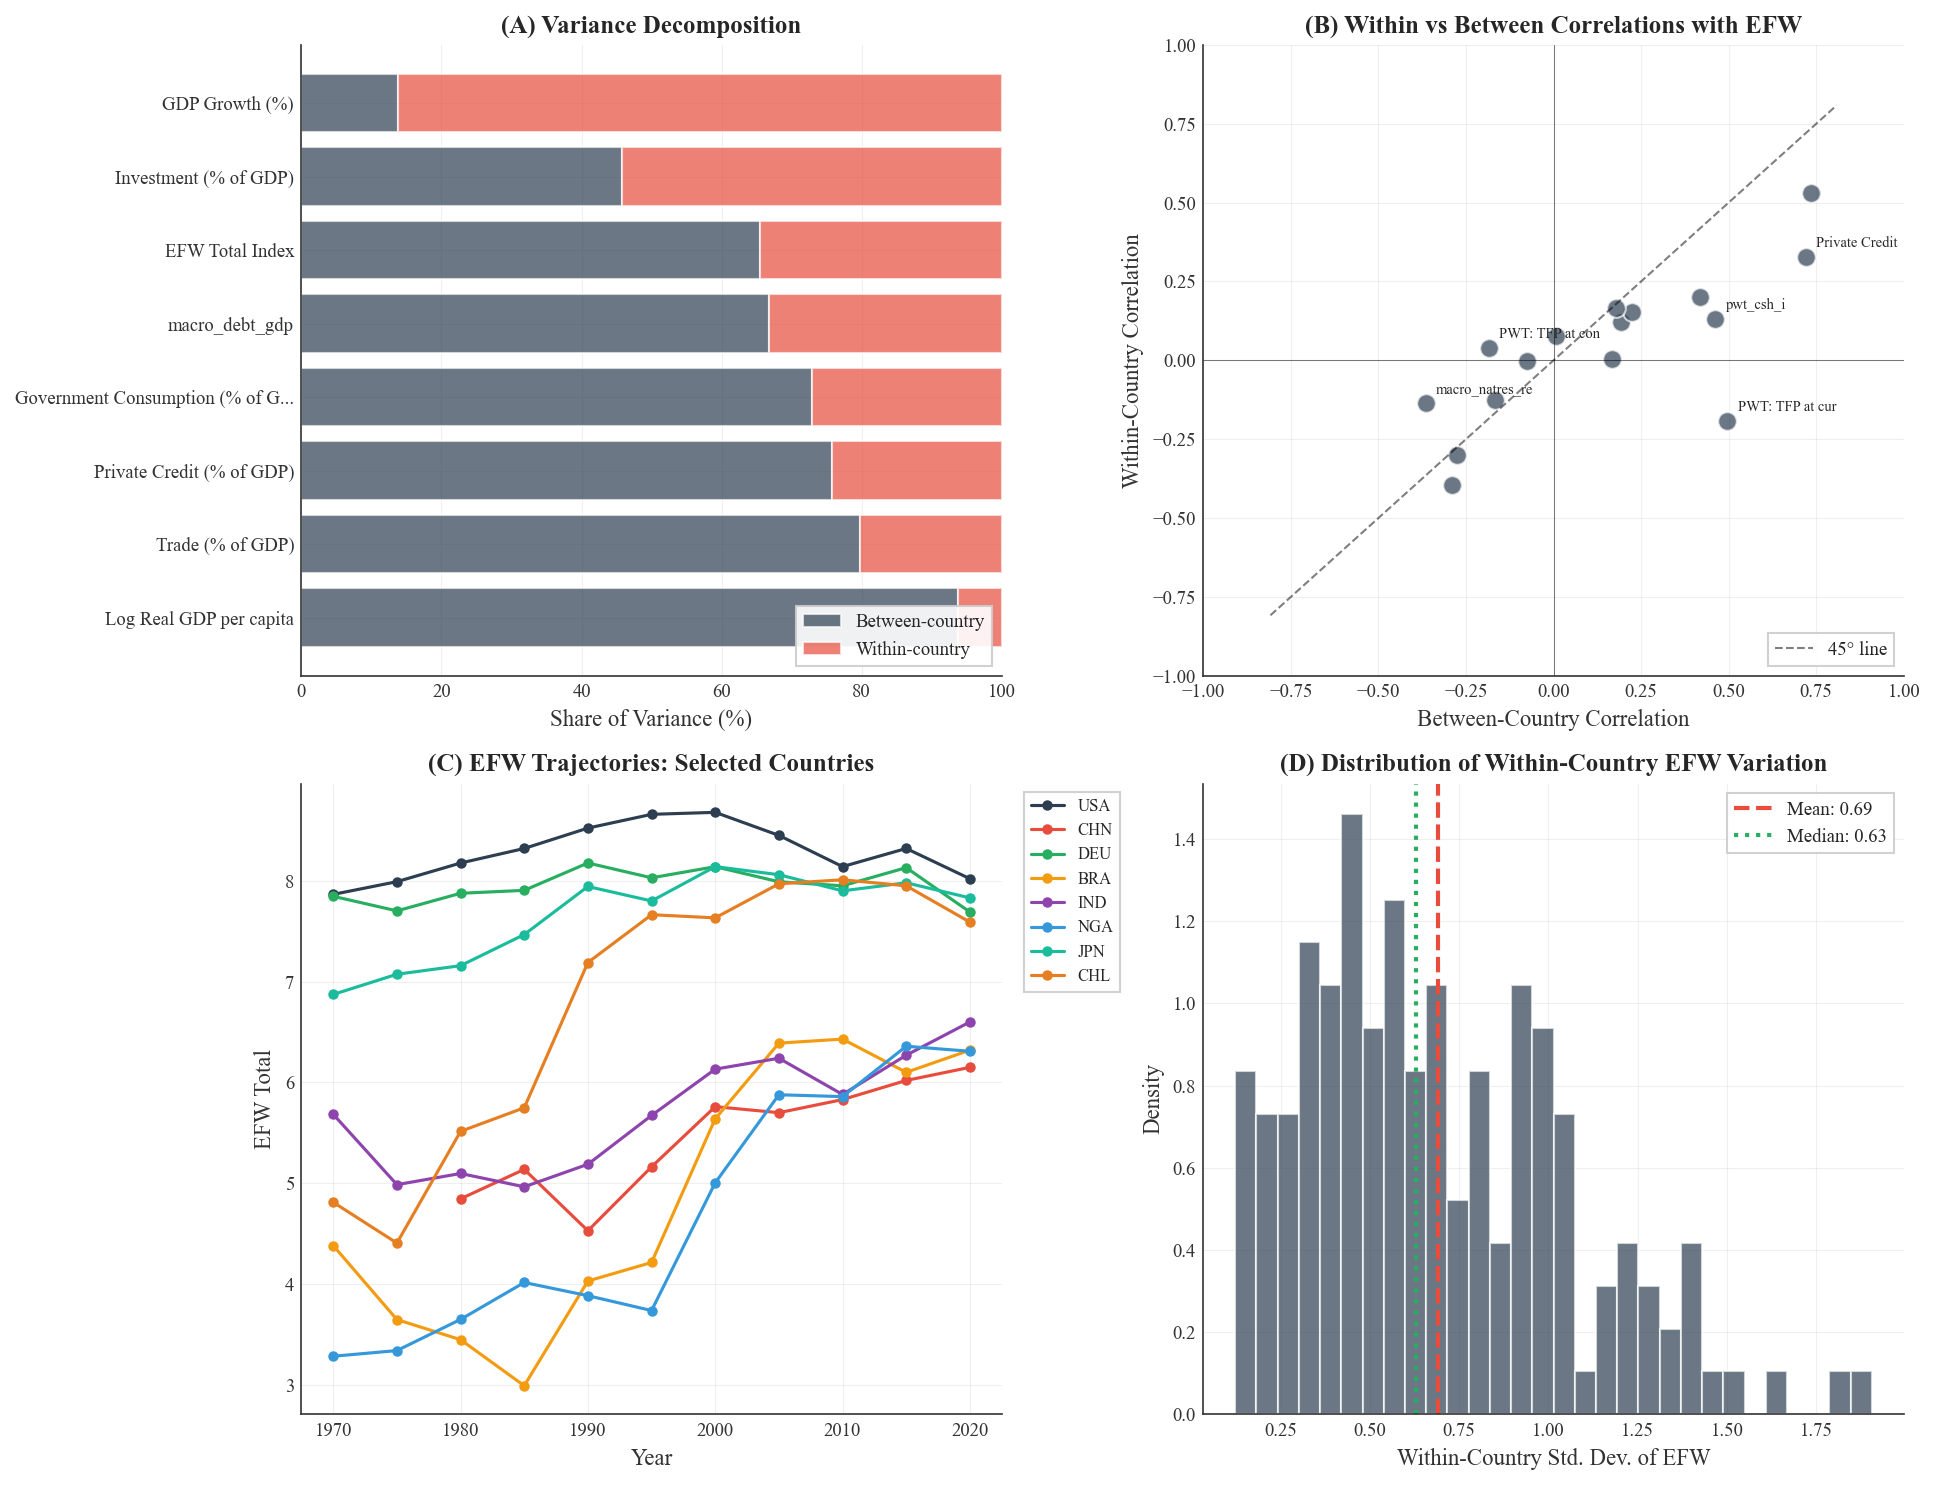


Figure 12: Within vs between-country variation
Key insight: If between-country variation dominates, cross-sectional correlations
             may reflect omitted country characteristics rather than causal effects.


In [100]:
# Figure 12: Within vs Between Variation
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Panel A: Variance decomposition bar chart
ax1 = axes[0, 0]
if decomp_results:
    decomp_plot = decomp_df.head(8).copy()
    y_pos = range(len(decomp_plot))
    
    ax1.barh(y_pos, decomp_plot['Between Share (%)'], color=PALETTE['primary'], alpha=0.7, 
             label='Between-country', edgecolor='white')
    ax1.barh(y_pos, decomp_plot['Within Share (%)'], left=decomp_plot['Between Share (%)'],
             color=PALETTE['secondary'], alpha=0.7, label='Within-country', edgecolor='white')
    
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels([v[:30] + '...' if len(v) > 30 else v for v in decomp_plot['Variable']])
    ax1.set_xlabel('Share of Variance (%)')
    ax1.set_title('(A) Variance Decomposition', fontweight='bold')
    ax1.legend(loc='lower right')
    ax1.set_xlim(0, 100)

# Panel B: Within vs Between correlations scatter
ax2 = axes[0, 1]
if wb_corr_results:
    ax2.scatter(wb_corr_df['Corr. Between'], wb_corr_df['Corr. Within'], 
                s=80, color=PALETTE['primary'], alpha=0.7, edgecolor='white', linewidth=1)
    
    # Add 45-degree line
    lim = max(abs(wb_corr_df[['Corr. Between', 'Corr. Within']].values.flatten().max()),
              abs(wb_corr_df[['Corr. Between', 'Corr. Within']].values.flatten().min())) * 1.1
    ax2.plot([-lim, lim], [-lim, lim], 'k--', linewidth=1, alpha=0.5, label='45° line')
    ax2.axhline(0, color='black', linewidth=0.5, alpha=0.5)
    ax2.axvline(0, color='black', linewidth=0.5, alpha=0.5)
    
    # Label outliers (large difference)
    for _, row in wb_corr_df.head(5).iterrows():
        ax2.annotate(row['Variable'][:15], 
                    (row['Corr. Between'], row['Corr. Within']),
                    xytext=(5, 5), textcoords='offset points', fontsize=7)
    
    ax2.set_xlabel('Between-Country Correlation')
    ax2.set_ylabel('Within-Country Correlation')
    ax2.set_title('(B) Within vs Between Correlations with EFW', fontweight='bold')
    ax2.legend(loc='lower right')
    ax2.set_xlim(-1, 1)
    ax2.set_ylim(-1, 1)

# Panel C: EFW time series for selected countries
ax3 = axes[1, 0]

# Select diverse countries with good coverage
selected_countries = ['USA', 'CHN', 'DEU', 'BRA', 'IND', 'NGA', 'JPN', 'CHL']
for i, iso in enumerate(selected_countries):
    country_data = panel[panel['iso3'] == iso][['year', 'efw_total']].dropna()
    if len(country_data) >= 3:
        ax3.plot(country_data['year'], country_data['efw_total'], 
                marker='o', markersize=4, label=iso, 
                color=CATEGORY_COLORS[i % len(CATEGORY_COLORS)], linewidth=1.5)

ax3.set_xlabel('Year')
ax3.set_ylabel('EFW Total')
ax3.set_title('(C) EFW Trajectories: Selected Countries', fontweight='bold')
ax3.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax3.set_xticks(QUINQUENNIAL_YEARS[::2])

# Panel D: Within-country variation distribution
ax4 = axes[1, 1]

# Compute within-country std for each country
within_std = panel.groupby('iso3')['efw_total'].std().dropna()

ax4.hist(within_std, bins=30, color=PALETTE['primary'], alpha=0.7, edgecolor='white', density=True)
ax4.axvline(within_std.mean(), color=PALETTE['secondary'], linewidth=2, linestyle='--',
            label=f'Mean: {within_std.mean():.2f}')
ax4.axvline(within_std.median(), color=PALETTE['tertiary'], linewidth=2, linestyle=':',
            label=f'Median: {within_std.median():.2f}')
ax4.set_xlabel('Within-Country Std. Dev. of EFW')
ax4.set_ylabel('Density')
ax4.set_title('(D) Distribution of Within-Country EFW Variation', fontweight='bold')
ax4.legend(loc='upper right')

plt.tight_layout()
save_fig('fig12_within_between_variation')
plt.show()

print("\nFigure 12: Within vs between-country variation")
print("Key insight: If between-country variation dominates, cross-sectional correlations")
print("             may reflect omitted country characteristics rather than causal effects.")

---

## Section VII: Multivariate Correlations and Partial Associations

Simple bivariate correlations can be misleading when variables are correlated with each other. This section examines:

1. **Correlation matrices** among EFW and macro variables
2. **Partial correlations** controlling for key confounders
3. **Correlation stability** across epochs

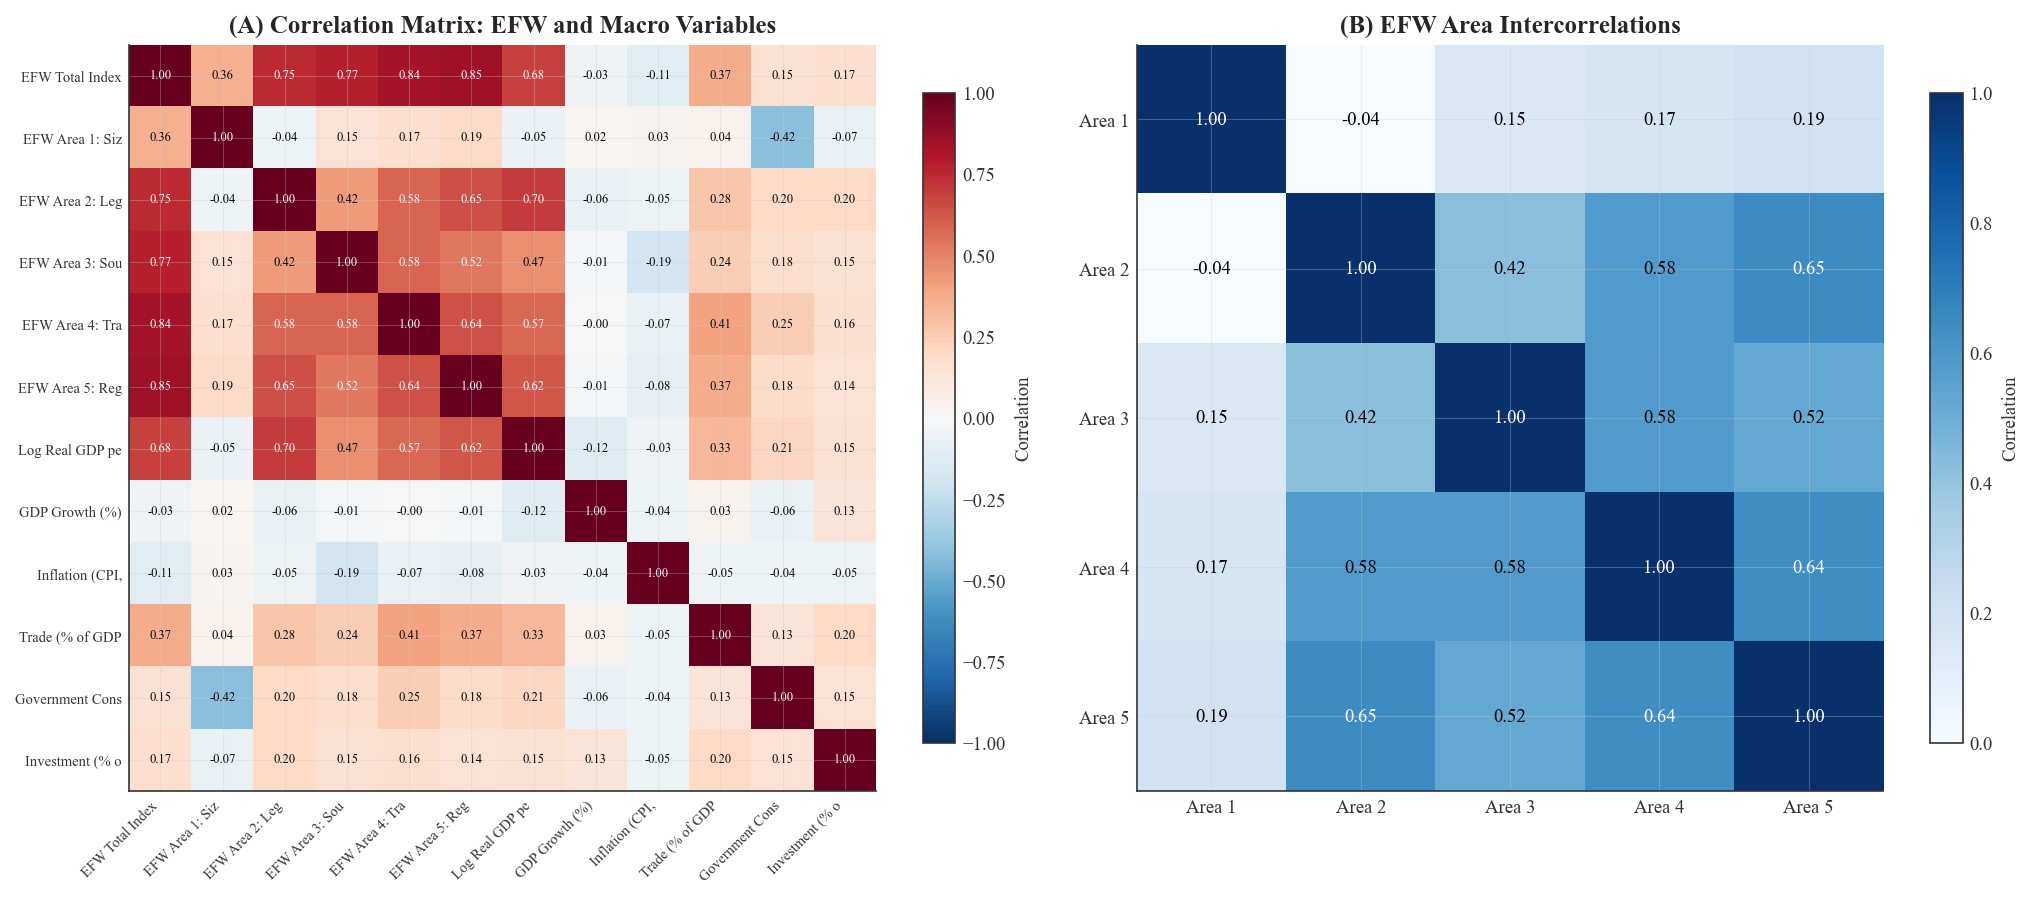

In [101]:
# =============================================================================
# SECTION VII: MULTIVARIATE CORRELATIONS AND PARTIAL ASSOCIATIONS
# =============================================================================

# -----------------------------------------------------------------------------
# VII.1 Correlation Matrix
# -----------------------------------------------------------------------------

# Select key variables for correlation analysis
corr_vars = ['efw_total', 'efw_area1', 'efw_area2', 'efw_area3', 'efw_area4', 'efw_area5']
corr_vars += [v for v in MACRO_VARS[:6] if v in panel.columns]

# Compute correlation matrix
corr_matrix = panel[corr_vars].corr()

# Figure 13: Correlation Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: Full correlation matrix
ax1 = axes[0]
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
im1 = ax1.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1)

# Add labels
labels = [VAR_LABELS.get(v, v)[:15] for v in corr_matrix.columns]
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
ax1.set_yticks(range(len(labels)))
ax1.set_yticklabels(labels, fontsize=7)
ax1.set_title('(A) Correlation Matrix: EFW and Macro Variables', fontweight='bold')

# Add text annotations
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        text_color = 'white' if abs(val) > 0.5 else 'black'
        ax1.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6, color=text_color)

cbar1 = plt.colorbar(im1, ax=ax1, shrink=0.8)
cbar1.set_label('Correlation', fontsize=9)

# Panel B: EFW areas intercorrelation
ax2 = axes[1]
efw_area_vars = [f'efw_area{i}' for i in range(1, 6) if f'efw_area{i}' in panel.columns]
if len(efw_area_vars) >= 3:
    efw_corr = panel[efw_area_vars].corr()
    
    im2 = ax2.imshow(efw_corr.values, cmap='Blues', vmin=0, vmax=1)
    labels2 = [f'Area {i}' for i in range(1, len(efw_area_vars) + 1)]
    ax2.set_xticks(range(len(labels2)))
    ax2.set_xticklabels(labels2)
    ax2.set_yticks(range(len(labels2)))
    ax2.set_yticklabels(labels2)
    ax2.set_title('(B) EFW Area Intercorrelations', fontweight='bold')
    
    for i in range(len(efw_corr)):
        for j in range(len(efw_corr.columns)):
            val = efw_corr.iloc[i, j]
            text_color = 'white' if val > 0.6 else 'black'
            ax2.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9, color=text_color)
    
    cbar2 = plt.colorbar(im2, ax=ax2, shrink=0.8)
    cbar2.set_label('Correlation', fontsize=9)

plt.tight_layout()
save_fig('fig13_correlation_matrices')
plt.show()

save_table(corr_matrix.reset_index(), 'table23_correlation_matrix')